# eCPA VLE Calculator: CO₂ – H₂O – NaCl

This notebook implements the **electrolyte Cubic Plus Association (eCPA)** equation of state for computing two-phase vapor–liquid equilibrium (VLE) properties of the CO₂ + H₂O + NaCl system. The implementation follows the formulation of Coelho, Franco & Firoozabadi (*Ind. Eng. Chem. Res.*, 2025). We also attempt to compare eCPA results to those from an independent salt-free CPA phase stability + flash model. And both models are compared to experimental data./


---

## System Overview

| Component | Index | Symbol |
|-----------|-------|--------|
| Water     | 1     | H₂O    |
| Sodium ion | 2    | Na⁺    |
| Chloride ion | 3  | Cl⁻    |
| Carbon dioxide | 4 | CO₂   |

**Salt** (NaCl) is treated as fully dissociated into Na⁺ and Cl⁻ and is assumed **non-volatile** — it partitions entirely into the aqueous phase.

---

## Notebook Structure

1. **Imports & Setup** — Python libraries
2. **Initial Guess Table** — Load and query precomputed salt-free CPA solutions
3. **Physical Constants & Parameters** — All thermodynamic constants
4. **ELV System** — The 10-variable equilibrium residual function
5. **Flash Algorithm** — Closed-system two-phase flash with molality continuation
6. **Validation & Checks** — Comparison with salt-free CPA2, tie-line invariance tests
7. **Convergence Scan** — Flash over full T–P grid, classifying outcomes
8. **Phase Envelope** — Visualisation of two-phase boundaries in T–P space
9. **Diagnostics** — Investigation of challenging/failing conditions

---

**Valid operating range:** 283 K ≤ T ≤ 533 K, 1 bar ≤ P ≤ 1500 bar, 0 ≤ m_NaCl ≤ ~6 mol/kg


---

## 1. Imports & Setup

Standard scientific Python stack. `brentq` from `scipy.optimize` is used for the outer scalar root-find in the flash algorithm; `fsolve` is used for the inner 10-variable ELV solve.


In [1]:
# --- Standard library ---
import os
import sys
import re
import time
import pickle
import warnings
import types
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- Numerical / scientific ---
import numpy as np
import pandas as pd
from scipy.optimize import fsolve, brentq
from scipy.interpolate import NearestNDInterpolator

# --- Plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
# from pylab import cm

# --- Other third-party ---
from colour import Color

# --- Local modules ---
import importlib
import CPA2
importlib.reload(CPA2)

<module 'CPA2' from '/home/moortgat.1/eCPA_SALTbasis/CPA2.py'>

In [2]:
# Use explicit complex Jacobian or default FD (which may actually be faster)
USE_COMPLEX_JAC = False   # set False to fall back to fsolve finite-difference Jacobian

---

## 2. Initial Guess Table

The ELV system is nonlinear and sensitive to initial guesses. To guarantee convergence, we use a precomputed table of **salt-free CPA solutions** (the `CPA_ELV_T###K.dat` files) as starting points.

### 2.1 Build the Parquet Cache

The individual per-temperature `.dat` files are consolidated once into a single Parquet file for fast lookup. Each row contains the converged 10-variable solution vector `[Zw, xw_W, eps_r, Zc, xw_C, chiw_W, chiw_C, Ndchi1w_dNw, Ndchi1w_dNc, Vdchi1w_dV]` at a given (T, P).


In [3]:
%%time
# Consolidate CO2/CPA_ELV_T###K.dat files into one Parquet file (saved in CO2/)

# --- paths (relative to your notebook, matching the existing code) ---
dat_dir = Path("CO2")                 # the folder your code uses: open("CO2/CPA_ELV_T{}K.dat")
out_path = dat_dir / "CPA_ELV_all.parquet"

# Explicit numeric column layout in each .dat row: P + 10 unknowns
_COLS = [
    "P_bar",
    "Z_W", "xw_W", "eps_r",
    "Z_C", "xw_C",
    "chiw_W", "chiw_C",
    "Ndchi1w_dNw", "Ndchi1w_dNc", "Vdchi1w_dV",
]

def read_cpa_elv_dat(path: Path) -> pd.DataFrame:
    # Infer T from filename like CPA_ELV_T288K.dat
    m = re.search(r"_T(\d+)K\.dat$", path.name)
    if not m:
        raise ValueError(f"Could not parse temperature from filename: {path.name}")
    T_K = int(m.group(1))

    # Skip the header line entirely (avoids the "P [bar]" split bug),
    # and read numeric data with explicit column names.
    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        skiprows=1,
        names=_COLS,
    )

    # Add temperature metadata
    df.insert(0, "T_K", T_K)

    return df


if out_path.exists():
    print(f"{out_path} already exists — skipping consolidation.")
else:
    # --- batch read ---
    paths = sorted(dat_dir.glob("CPA_ELV_T*K.dat"))
    if not paths:
        raise FileNotFoundError(f"No files matching {dat_dir/'CPA_ELV_T*K.dat'}")

    dfs = [read_cpa_elv_dat(p) for p in paths]
    all_df = pd.concat(dfs, ignore_index=True)

    # Helpful for fast lookup later
    all_df = all_df.sort_values(["T_K", "P_bar"]).reset_index(drop=True)

    # --- write parquet ---
    all_df.to_parquet(out_path, index=False)

    print(f"Wrote: {out_path}")
    print(f"Rows: {len(all_df):,} | Columns: {len(all_df.columns)}")
    print("Temperatures:", sorted(all_df["T_K"].unique())[:10],
          ("..." if all_df["T_K"].nunique() > 10 else ""))
    print("Columns:", list(all_df.columns))



CO2/CPA_ELV_all.parquet already exists — skipping consolidation.
CPU times: user 265 µs, sys: 0 ns, total: 265 µs
Wall time: 618 µs


### 2.2 Load Table into Memory

Groups the table by temperature for fast nearest-neighbour and interpolated lookup.


In [4]:
def load_cpa_guess_table(parquet_path="CO2/CPA_ELV_all.parquet"):
    parquet_path = Path(parquet_path)
    if not parquet_path.exists():
        raise FileNotFoundError(f"{parquet_path} not found.")

    df = pd.read_parquet(parquet_path)

    # Drop the stray header fragment column if present
    if "[bar]" in df.columns:
        df = df.drop(columns=["[bar]"])

    # Normalize names to what our solver expects
    rename_map = {
        "Z_W": "Zw",
        "Z_C": "Zc",
        "xw_W": "xw_W",   # keep
        "xw_C": "xw_C",   # keep
        "eps_r": "eps_r", # keep
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    required = [
        "T_K", "P_bar",
        "Zw", "xw_W", "eps_r", "Zc", "xw_C",
        "chiw_W", "chiw_C",
        "Ndchi1w_dNw", "Ndchi1w_dNc", "Vdchi1w_dV",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {parquet_path}: {missing}")

    df = df.sort_values(["T_K", "P_bar"]).reset_index(drop=True)

    groups = {}
    for T, sub in df.groupby("T_K"):
        groups[int(T)] = sub.sort_values("P_bar").reset_index(drop=True)

    temps = np.array(sorted(groups.keys()), dtype=float)
    return groups, temps


### 2.3 Nearest-Neighbour Lookup (legacy)

Simple nearest-neighbour lookup — snaps to the closest available (T, P) in the table. Kept for reference; the bilinear interpolation below is preferred.


In [5]:
def guess_from_table_nearest(T, P_bar, groups, temps):
    if len(temps) == 0:
        raise ValueError("No temperatures available in guess table.")

    T_closest = temps[np.argmin(np.abs(temps - T))]
    dfT = groups[int(T_closest)]

    Pvals = dfT["P_bar"].to_numpy(dtype=float)
    idx = int(np.argmin(np.abs(Pvals - P_bar)))
    row = dfT.iloc[idx]

    return np.array([
        row["Zw"],
        row["xw_W"],
        row["eps_r"],
        row["Zc"],
        row["xw_C"],
        row["chiw_W"],
        row["chiw_C"],
        row["Ndchi1w_dNw"],
        row["Ndchi1w_dNc"],
        row["Vdchi1w_dV"],
    ], dtype=np.float64)


### 2.4 Bilinear Interpolation Lookup (preferred)

Bilinear interpolation in (T, P) space is expected to provide a smoother, more accurate initial guess between table points — particularly important away from the grid nodes.


In [6]:
# Linearly interpolate initial guess instead of nearest
def guess_from_table(T, P_bar, groups, temps):
    if len(temps) == 0:
        raise ValueError("No temperatures available in guess table.")

    # --- Temperature interpolation weight ---
    idx_T = np.searchsorted(temps, T)
    idx_T = np.clip(idx_T, 1, len(temps) - 1)
    T_lo, T_hi = temps[idx_T - 1], temps[idx_T]
    wT = (T - T_lo) / (T_hi - T_lo) if T_hi != T_lo else 0.0

    def interp_at_T(T_key, P_bar):
        dfT = groups[int(T_key)]
        Pvals = dfT["P_bar"].to_numpy(dtype=float)
        idx_P = np.searchsorted(Pvals, P_bar)
        idx_P = np.clip(idx_P, 1, len(Pvals) - 1)
        P_lo, P_hi = Pvals[idx_P - 1], Pvals[idx_P]
        wP = (P_bar - P_lo) / (P_hi - P_lo) if P_hi != P_lo else 0.0
        row_lo = dfT.iloc[idx_P - 1]
        row_hi = dfT.iloc[idx_P]
        cols = ["Zw", "xw_W", "eps_r", "Zc", "xw_C",
                "chiw_W", "chiw_C", "Ndchi1w_dNw", "Ndchi1w_dNc", "Vdchi1w_dV"]
        v_lo = np.array([row_lo[c] for c in cols], dtype=np.float64)
        v_hi = np.array([row_hi[c] for c in cols], dtype=np.float64)
        return v_lo + wP * (v_hi - v_lo)

    guess_lo = interp_at_T(T_lo, P_bar)
    guess_hi = interp_at_T(T_hi, P_bar)
    return guess_lo + wT * (guess_hi - guess_lo)

### 2.5 Initialise Lookup

Run once per kernel session to load the table into memory as grouped DataFrames.


In [7]:
%%time
# One-time setup: load guess table into memory
CPA_GROUPS, CPA_TEMPS = load_cpa_guess_table("CO2/CPA_ELV_all.parquet")
print(f"Loaded table: {len(CPA_TEMPS)} temperatures, "
      f"T = {CPA_TEMPS[0]:.0f}–{CPA_TEMPS[-1]:.0f} K")


Loaded table: 251 temperatures, T = 283–533 K
CPU times: user 240 ms, sys: 117 ms, total: 357 ms
Wall time: 350 ms


### 2.6 Convenience Wrapper

Wraps the bilinear lookup to round T to the nearest integer before querying (matching the original integer-temperature convention of the `.dat` files).

 (defined below) returns the pressure range covered by the table at a given T — used by the scan loop and the composition plot to clip the P grid to valid table coverage.


In [8]:
def guess_table_fn(T, P_bar):
    # mimic your earlier integer-T snapping if you want:
    t = int(round(T))
    return guess_from_table(t, P_bar, CPA_GROUPS, CPA_TEMPS)


In [9]:
def get_table_p_range(T, groups, temps):
    """Return (P_min, P_max) available in the guess table at this T."""
    T_closest = temps[np.argmin(np.abs(temps - T))]
    dfT = groups[int(T_closest)]
    return float(dfT["P_bar"].min()), float(dfT["P_bar"].max())

### 2.7 Visualize CPA Compositions

Below is a figure of the water composition in the aqueous and gas phases at different temperatures from CPA computations without salt. These will be used as initial guesses for the eCPA VLE and flash computations below.

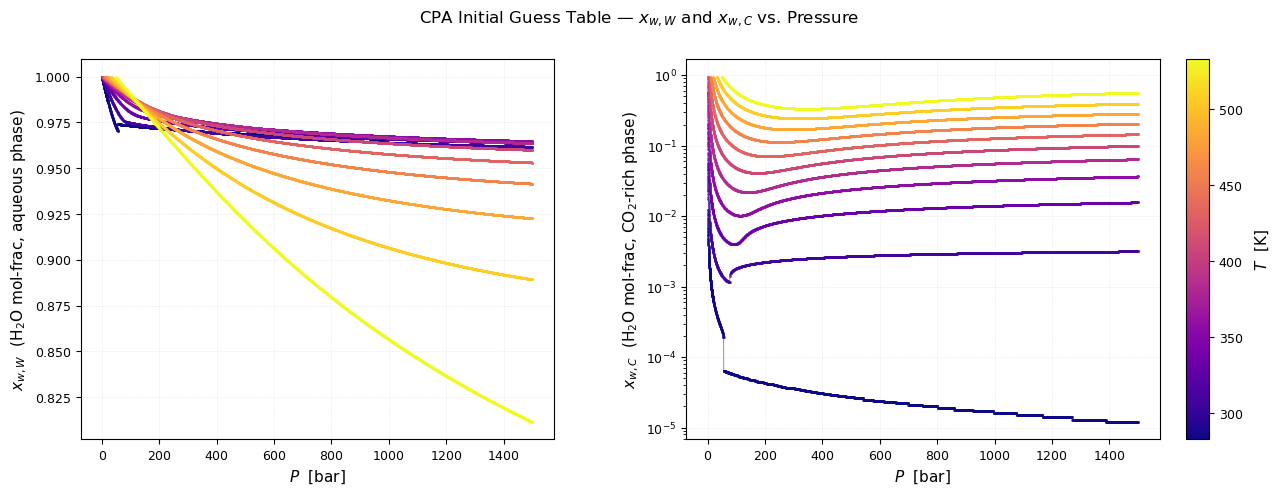

In [10]:
# ── 2.7  Initial Guess Table — x_{w,W} and x_{w,C} vs. Pressure ─────────────
#
# Two panels side by side; temperatures colour-mapped with plasma.
# Markers = actual table points; thin lines connect within each temperature.
# ─────────────────────────────────────────────────────────────────────────────
PANELS = [
    ("xw_W", r"$x_{w,W}$  (H$_2$O mol-frac, aqueous phase)",       False),
    ("xw_C", r"$x_{w,C}$  (H$_2$O mol-frac, CO$_2$-rich phase)",   True),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(left=0.07, right=0.90, bottom=0.12, top=0.88, wspace=0.28)

T_all = np.array(sorted(CPA_GROUPS.keys()), dtype=float)[::25]
T_min, T_max = T_all.min(), T_all.max()
cmap   = cm.plasma
norm   = mcolors.Normalize(vmin=T_min, vmax=T_max)

for ax, (col, ylabel, use_log) in zip(axes, PANELS):
    for T_K in T_all:
        dfT   = CPA_GROUPS[int(T_K)]
        P_arr = dfT["P_bar"].to_numpy(dtype=float)
        y_arr = dfT[col].to_numpy(dtype=float)
        color = cmap(norm(T_K))

        ax.plot(P_arr, y_arr, lw=0.6, color=color, alpha=0.55, zorder=1)
        ax.scatter(P_arr, y_arr, s=4, color=color, alpha=0.75,
                   linewidths=0, zorder=2)

    ax.set_xlabel(r"$P$  [bar]", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(labelsize=9)
    ax.grid(True, ls=":", lw=0.4, alpha=0.5)
    if use_log:
        ax.set_yscale("log")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r"$T$  [K]", fontsize=11, labelpad=8)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(r"CPA Initial Guess Table — $x_{w,W}$ and $x_{w,C}$ vs. Pressure",
             fontsize=12)

plt.savefig("results/guess_xw_overview.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 3. Physical Constants & Thermodynamic Parameters

### 3.1 Universal Constants


In [11]:
####### CONSTANTS
R = 8.314                   # J/mol.K
Na = 6.02e23                # 1/mol
kb = 1.38e-23               # J/K
e = 1.6e-19                 # C
eps0 = 8.854e-12            # F/m
Mw = 0.018                  # kg/mol
Ms = 0.0585                 # kg/mol
Mc = 0.044                  # kg/mol
Tc1 = 647.29                # K
Pc1 = 22060000              # Pa
Tc4 = 304.4                 # K
Pc4 = 7380000               # Pa

### 3.2 CPA/eCPA Model Parameters

These are the fitted parameters of the eCPA equation of state for the CO₂ + H₂O + NaCl system.

**Physical (SRK-type EoS):**
- `b1`, `b4`: co-volume parameters for H₂O and CO₂ (m³/mol)
- `a01`, `a04`: energy parameters for H₂O and CO₂
- `c11`, `c14`: Mathias–Copeman temperature-correction coefficients
- `Akij`, `Bkij`, `Ckij`: temperature-dependent binary interaction parameter k₁₄(T)
- `ASij`, `BSij`, `CSij`: cross-association interaction S₁₄(T)

**Association (Wertheim theory):**
- `epsW`: association energy (K/kB)
- `kappaW`: association volume (m³/mol)

**Ions:**
- `Z2`, `Z3`: valences of Na⁺ and Cl⁻
- `Sg2`, `Sg3`: ionic diameters (m)
- `Rb2`, `Rb3`: Born radii (m)
- `Uref1s`, `Uref4s`: reference Huron–Vidal interaction energies

**Permittivity:**
- `dip01`, `pol1`–`pol4`: dipole moment and polarisabilities for Kirkwood–Onsager model
- `GAMMA1`, `THETA1`: molecular geometry angles for water


In [12]:
# Physical
b1 = 14.515e-6               # m³/mol
c11 = 0.6736                 
a01 = 1017.3*R*b1            # J.m³/mol²
a02 = 0 
b2 = 16.49e-6                # m³/mol
a03 = 0
b3 = 40.83e-6                # m³/mol
b4 = 27.2e-6                 # m³/mol
c14 = 0.7602                
a04 = 1551.2*R*b4            # J.m³/mol
Tref = 298.15                # K
Akij = -0.49206
Bkij = 2.10136
Ckij = -1.57135
ASij = 0.19173
BSij = -0.17299
CSij = -0.00909

# Association
epsW = 2003.25               # K (/kb)
bettaW = 69.2e-3
kappaW = bettaW*b1           # m³/mol

# Ions
Z2 = 1
Z3 = -1
Sg2 = 2.356e-10
Sg3 = 3.187e-10
Rb2 = 1.665e-10
Rb3 = 1.828e-10
Penelouxs = -53.5e-6
Uref1s = -223.5*R            # J/mol
Talfa1s = 340                # K
alfa1s = 1573                # K
Uref4s = 6056.13852
Talfa4s = 243.79352
alfa4s = 691.85326

# Permissivity
dip01 = 1.8546*3.335e-30     # C.m
pol1 = 1.6133e-40            # Cm²/J
pol2 = 2.221e-40             # Cm²/J
pol3 = 3.557e-40             # Cm²/J
pol4 = 2.6946e-40            # Cm²/J
GAMMA1 = 63.4715*np.pi/180   # rad
THETA1 = 94.7939*np.pi/180   # rad
zww = 4

### 3.3 Snapshot Constants into `params` Dict

The `ELV` function accepts an optional `params` dict so the solver can be called with different parameter sets without modifying global state. This cell captures all current numeric globals into that dict.


In [13]:
def make_params_from_globals(include_names=None, exclude_names=None):
    """
    Snapshot numeric constants from current module globals
    into a dict suitable for passing as `params` to ELV().

    Parameters
    ----------
    include_names : list[str] or None
        If provided, only include these variable names.
    exclude_names : list[str] or None
        If provided, exclude these variable names.

    Returns
    -------
    params : dict[str -> float64]
    """

    g = globals()
    params = {}

    for name, value in g.items():

        # Skip private/internal names
        if name.startswith("_"):
            continue

        # Optional inclusion filter
        if include_names is not None and name not in include_names:
            continue

        # Optional exclusion filter
        if exclude_names is not None and name in exclude_names:
            continue

        # Skip modules, functions, classes
        if isinstance(value, (types.ModuleType, types.FunctionType, type)):
            continue

        # Keep only scalar numeric values
        if isinstance(value, (int, float, np.floating, np.integer)):
            params[name] = np.float64(value)

        # Allow numpy scalar types
        elif isinstance(value, np.ndarray) and value.shape == ():
            params[name] = np.float64(value)

        # Skip arrays, lists, etc.
        else:
            continue

    return params


In [14]:
params = make_params_from_globals()

---

## 3.4 Experimental Data: CO₂–H₂O (Salt-Free)

The code below (tries to) create a unform efficient file structure for all (salt-free) experimental data for CO2-H2O mixtures and their phase compositions. '

In [15]:
%%time
# ─────────────────────────────────────────────────────────────────────────────
# CO2–Water experimental VLE data: parse folder → Parquet + lookup helpers
#
# Dataset columns
# ───────────────
#   T_K         temperature [K]
#   P_bar       pressure [bar]
#   xc_W        CO2 mol-frac in the aqueous (water-rich) phase
#   yw_C        H2O mol-frac in the CO2-rich phase
#   rho_W       aqueous-phase density [kg/m³]  (sparse, 37 pts)
#   exp_id      experiment number within that T folder
#   reference   author/year string from the file's # header line
#   source_file original filename
#
# Missing measurements are NaN (originally 'X' or 'x' in the source files).
# The one '(copy)' file in T423K is excluded.
# Column header is parsed to handle both conventions:
#   yw_C  → H2O mol-frac in CO2-rich phase  (stored as-is)
#   yc_C  → CO2 mol-frac in CO2-rich phase  (converted: yw_C = 1 - yc_C)
#
# Usage
# ─────
#   exp_xc_W(323)   → DataFrame of CO2-solubility points at 323 K
#   exp_yw_C(323)   → DataFrame of H2O-in-CO2 points at 323 K
#   exp_at_T(323)   → all rows at 323 K (both quantities)
# ─────────────────────────────────────────────────────────────────────────────

import re
import numpy as np
import pandas as pd
from pathlib import Path

_DATA_DIR     = Path("EXP/CO2-WATER")
_PARQUET_PATH = Path("CO2/CO2_WATER_exp.parquet")


def _parse_co2water_dir(data_dir: Path) -> pd.DataFrame:
    """Read every EXP*.txt in the extracted CO2-WATER folder."""
    records = []

    for txt_path in sorted(data_dir.rglob("EXP*.txt")):
        if '(copy)' in txt_path.name.lower():
            continue

        m_T = re.search(r'T(\d+)K', str(txt_path))
        if not m_T:
            continue
        T_K = int(m_T.group(1))

        m_exp = re.search(r'EXP(\d+)_', txt_path.name)
        exp_id = int(m_exp.group(1)) if m_exp else 0

        lines = txt_path.read_text(encoding='utf-8', errors='replace').splitlines()

        # First '#' line → reference string
        reference, data_start = '', 0
        for i, line in enumerate(lines):
            if line.strip().startswith('#'):
                reference  = line.strip().lstrip('#').strip()
                data_start = i + 1
                break

        # Next non-empty non-comment line → column header: parse it
        col_xc_W  = 1       # default column indices
        col_yw_C  = 2
        col_rho   = 3
        yc_C_mode = False   # True when col 2 is CO2 mol-frac → invert to get H2O

        for i in range(data_start, len(lines)):
            line = lines[i].strip()
            if line and not line.startswith('#'):
                # join and re-split after removing the "P [bar]" prefix
                # so that bracketed units don't shift column indices
                cleaned = re.sub(r'\[.*?\]', '', line)   # drop [...] tokens
                headers = cleaned.lower().split()
                for j, h in enumerate(headers):
                    if h == 'xc_w':
                        col_xc_W = j
                    if h == 'yw_c':
                        col_yw_C  = j
                        yc_C_mode = False
                    if h == 'yc_c':
                        col_yw_C  = j
                        yc_C_mode = True
                    if 'rho' in h:
                        col_rho = j
                data_start = i + 1
                break

        def _v(s: str) -> float:
            """'X' / 'x' → NaN, else float."""
            return np.nan if s.lower() == 'x' else float(s)

        for line in lines[data_start:]:
            parts = line.strip().split()
            if len(parts) < 2 or parts[0].startswith('#'):
                continue
            try:
                raw_y = _v(parts[col_yw_C]) if len(parts) > col_yw_C else np.nan
                yw_C  = (1.0 - raw_y) if (yc_C_mode and np.isfinite(raw_y)) else raw_y

                records.append(dict(
                    T_K         = T_K,
                    P_bar       = float(parts[0]),
                    xc_W        = _v(parts[col_xc_W]) if len(parts) > col_xc_W else np.nan,
                    yw_C        = yw_C,
                    rho_W       = _v(parts[col_rho])  if len(parts) > col_rho  else np.nan,
                    exp_id      = exp_id,
                    reference   = reference,
                    source_file = txt_path.name,
                ))
            except (ValueError, IndexError):
                continue

    df = pd.DataFrame(records)
    return df.sort_values(['T_K', 'P_bar', 'exp_id']).reset_index(drop=True)


# ── Build or load Parquet ─────────────────────────────────────────────────────
_PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)

if _PARQUET_PATH.exists():
    EXP_DF = pd.read_parquet(_PARQUET_PATH)
    print(f"Loaded  {_PARQUET_PATH}  ({len(EXP_DF)} rows)")
else:
    print(f"Parsing {_DATA_DIR} ...")
    EXP_DF = _parse_co2water_dir(_DATA_DIR)
    EXP_DF.to_parquet(_PARQUET_PATH, index=False)
    print(f"Saved   {_PARQUET_PATH}  ({len(EXP_DF)} rows)")

EXP_TEMPS = np.array(sorted(EXP_DF['T_K'].unique()), dtype=float)


# ── Lookup helpers ────────────────────────────────────────────────────────────

def exp_at_T(T_K: float, tol_K: float = 1.0) -> pd.DataFrame:
    """All experimental rows within ±tol_K of T_K."""
    return EXP_DF[np.abs(EXP_DF['T_K'] - T_K) <= tol_K].copy()


def exp_xc_W(T_K: float, tol_K: float = 1.0) -> pd.DataFrame:
    """CO2 solubility rows (xc_W not NaN) near T_K."""
    df = exp_at_T(T_K, tol_K)
    return df[df['xc_W'].notna()][['P_bar', 'xc_W', 'reference']].copy()


def exp_yw_C(T_K: float, tol_K: float = 1.0) -> pd.DataFrame:
    """H2O content in CO2-rich phase (yw_C not NaN) near T_K."""
    df = exp_at_T(T_K, tol_K)
    return df[df['yw_C'].notna()][['P_bar', 'yw_C', 'reference']].copy()


# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nDataset summary")
print(f"  Rows      : {len(EXP_DF)}")
print(f"  T range   : {int(EXP_DF['T_K'].min())}–{int(EXP_DF['T_K'].max())} K  "
      f"({EXP_DF['T_K'].nunique()} isotherms)")
print(f"  P range   : {EXP_DF['P_bar'].min():.1f}–{EXP_DF['P_bar'].max():.0f} bar")
print(f"  xc_W pts  : {EXP_DF['xc_W'].notna().sum()}")
print(f"  yw_C pts  : {EXP_DF['yw_C'].notna().sum()}")
print(f"  rho_W pts : {EXP_DF['rho_W'].notna().sum()}")
print(f"  Sources   : {EXP_DF['reference'].nunique()} references")
print()
print(EXP_DF.groupby('T_K').agg(
    n      = ('P_bar',     'count'),
    xc_W   = ('xc_W',     lambda x: x.notna().sum()),
    yw_C   = ('yw_C',     lambda x: x.notna().sum()),
    P_min  = ('P_bar',    'min'),
    P_max  = ('P_bar',    'max'),
    n_refs = ('reference','nunique'),
).to_string())

Loaded  CO2/CO2_WATER_exp.parquet  (631 rows)

Dataset summary
  Rows      : 631
  T range   : 273–623 K  (35 isotherms)
  P range   : 4.7–3500 bar
  xc_W pts  : 560
  yw_C pts  : 452
  rho_W pts : 37
  Sources   : 18 references

      n  xc_W  yw_C   P_min    P_max  n_refs
T_K                                         
273   5     5     0  100.00   500.00       1
278  10    10     3    5.01   400.00       2
283  13     5     8    5.00   500.00       2
288  21    19    10    4.96   400.00       3
293  22    11    16    5.00  1200.00       3
298  23    23    13    5.04   500.00       4
304  15     5    15    5.00   204.00       2
308  14     9    13    5.79   202.70       2
313  22     8    14    5.00  1200.00       3
318  10    10     8    4.65    79.33       1
323  41    41    35   10.60  3500.00       7
333  28    18    20    5.00  1200.00       3
348  11    10    11   11.00   209.40       3
353  32    22    19    5.00  1200.00       4
373  32    32    20    6.00  3500.00       5
383  

### 3.5 CPA Phase Stability vs. Experimental Data

Below, we compare stand-alone CPA predictions to experimental data, using an older CPA code that does full phase stability + flash for multicomponent mixtures. Flash computations are done for a feed compositions of 50mol% CO2 and 50mol% H2O. 

In [16]:
# ── must be top-level for ProcessPoolExecutor to pickle it ──────────────────
def _cpa2_vle_worker(args):
    import CPA2, numpy as np, warnings
    T_K, P_bar = args[0], args[1]
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out = CPA2.flash_co2_h2o_tpz(T=float(T_K), P_bar=float(P_bar), z_co2=0.5)
        if out["phase"] != "two_phase":
            return T_K, P_bar, np.nan, np.nan
        return T_K, P_bar, float(out["x"][0]), float(out["y"][1])
    except Exception:
        return T_K, P_bar, np.nan, np.nan


def plot_cpa2_vs_exp(
        T_list,
        N_P=40,
        n_workers=48,
        save_path="results/cpa2_vs_exp.png"):
    """
    Grid of len(T_list) rows x 2 columns.
    Left  col: xc_W  -- CO2 mol-frac in aqueous phase
    Right col: yw_C  -- H2O mol-frac in CO2-rich phase  (log scale)

    Solid line  = CPA2 flash on a fine P grid (range taken from exp data)
    Symbols     = experimental data (coloured by reference)
    """
    from concurrent.futures import ProcessPoolExecutor, as_completed

    # ── per-temperature P grids from experimental range ───────────────────────
    tasks   = []
    P_grids = {}
    for T_K in T_list:
        df_T = exp_at_T(T_K, tol_K=1.0)
        P_lo = df_T["P_bar"].min()
        P_hi = df_T["P_bar"].max()
        P_grids[T_K] = np.linspace(P_lo, P_hi, N_P)
        for P in P_grids[T_K]:
            tasks.append((T_K, P))

    # ── parallel CPA2 flashes ─────────────────────────────────────────────────
    raw = {}
    with ProcessPoolExecutor(max_workers=min(n_workers, len(tasks))) as ex:
        futs = {ex.submit(_cpa2_vle_worker, t): t for t in tasks}
        for fut in as_completed(futs):
            T_K, P, xc_W, yw_C = fut.result()
            raw[(T_K, round(float(P), 6))] = (xc_W, yw_C)

    cpa2 = {}
    for T_K in T_list:
        P_grid = P_grids[T_K]
        vals = [raw.get((T_K, round(float(P), 6)), (np.nan, np.nan)) for P in P_grid]
        cpa2[T_K] = dict(
            P    = P_grid,
            xc_W = np.array([v[0] for v in vals]),
            yw_C = np.array([v[1] for v in vals]),
        )

    # ── figure ────────────────────────────────────────────────────────────────
    n_rows = len(T_list)
    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(11, 2.8 * n_rows),
                             squeeze=False)
    fig.subplots_adjust(left=0.09, right=0.97, bottom=0.04,
                        top=0.96, hspace=0.55, wspace=0.30)

    # fixed colour cycle for references across all panels
    all_refs  = sorted(EXP_DF['reference'].unique())
    ref_color = {r: plt.cm.tab20(i / max(len(all_refs)-1, 1))
                 for i, r in enumerate(all_refs)}

    for row, T_K in enumerate(T_list):
        ax_x = axes[row, 0]
        ax_y = axes[row, 1]

        # ── CPA2 lines ────────────────────────────────────────────────────
        d = cpa2[T_K]
        mask = np.isfinite(d["xc_W"])
        if mask.any():
            ax_x.plot(d["P"][mask], d["xc_W"][mask], "k-", lw=1.4, zorder=3)
        mask = np.isfinite(d["yw_C"])
        if mask.any():
            ax_y.plot(d["P"][mask], d["yw_C"][mask], "k-", lw=1.4, zorder=3)

        # ── experimental symbols ──────────────────────────────────────────
        df_T = exp_at_T(T_K, tol_K=1.0)
        seen_refs = set()
        for _, grp in df_T.groupby("reference"):
            ref   = grp["reference"].iloc[0]
            color = ref_color[ref]
            label = ref if ref not in seen_refs else "_nolegend_"
            seen_refs.add(ref)

            sub_x = grp[grp["xc_W"].notna()]
            if not sub_x.empty:
                ax_x.scatter(sub_x["P_bar"], sub_x["xc_W"],
                             s=28, color=color, zorder=4,
                             label=label, linewidths=0)

            sub_y = grp[grp["yw_C"].notna()]
            if not sub_y.empty:
                ax_y.scatter(sub_y["P_bar"], sub_y["yw_C"],
                             s=28, color=color, zorder=4,
                             label=label, linewidths=0)

        # ── axes formatting ───────────────────────────────────────────────
        for ax in (ax_x, ax_y):
            ax.set_xlabel("$P$ [bar]", fontsize=9)
            ax.set_xlim(left=0)
            ax.grid(True, ls=":", lw=0.4, alpha=0.5)
            ax.tick_params(labelsize=8)

        ax_x.set_ylabel("$x_{c,W}$  (CO$_2$ in aq.)", fontsize=9)
        ax_y.set_ylabel("$y_{w,C}$  (H$_2$O in CO$_2$)", fontsize=9)
        ax_y.set_yscale("log")

        # temperature label as row title
        fig.text(0.5, axes[row, 0].get_position().y1 + 0.005,
                 f"$T = {T_K}$ K",
                 ha="center", va="bottom", fontsize=10, fontweight="bold",
                 transform=fig.transFigure)

    fig.suptitle("CPA2 vs. Experiment --- CO$_2$-H$_2$O VLE",
                 fontsize=12, y=0.99)

    os.makedirs("results", exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


Next, we perform a similar comparison between experimental data and the initial guesses constructed from eCPA for ms-> 0 (salt-free). 

In [18]:
def plot_ecpa_table_vs_exp(
        T_list,
        N_P=40,
        save_path="results/ecpa_table_vs_exp.png"):
    """
    Grid of len(T_list) rows × 2 columns.
    Left  col: xc_W  — CO2 mol-frac in aqueous phase
    Right col: yw_C  — H2O mol-frac in CO2-rich phase  (log scale)

    Solid line  = eCPA table interpolated onto exp P range  (salt-free)
    Symbols     = experimental data (coloured by reference)

    Table columns used:
      xc_W  =  1 - xw_W   (CO2 mol-frac in aqueous  = 1 minus H2O mol-frac)
      yw_C  =  xw_C        (H2O mol-frac in CO2-rich, directly)
    """
    P_MAX = 1000.0  # <-- hard cap for both computed/displayed pressure range

    # ── figure ────────────────────────────────────────────────────────────────
    n_rows = len(T_list)
    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(11, 2.8 * n_rows),
        squeeze=False
    )
    fig.subplots_adjust(
        left=0.09, right=0.97, bottom=0.04,
        top=0.96, hspace=0.55, wspace=0.30
    )

    all_refs = sorted(EXP_DF["reference"].unique())
    ref_color = {
        r: plt.cm.tab20(i / max(len(all_refs) - 1, 1))
        for i, r in enumerate(all_refs)
    }

    for row, T_K in enumerate(T_list):
        ax_x = axes[row, 0]
        ax_y = axes[row, 1]

        # Filter experimental data to <= P_MAX once and reuse everywhere
        df_T = exp_at_T(T_K, tol_K=1.0)
        df_T = df_T[df_T["P_bar"] <= P_MAX].copy()

        # ── eCPA table line ───────────────────────────────────────────────
        T_near = int(CPA_TEMPS[np.argmin(np.abs(CPA_TEMPS - T_K))])
        if T_near in CPA_GROUPS and not df_T.empty:
            tab = CPA_GROUPS[T_near].sort_values("P_bar")
            P_tab  = tab["P_bar"].to_numpy(dtype=float)
            xc_tab = 1.0 - tab["xw_W"].to_numpy(dtype=float)  # CO2 in aqueous
            yw_tab = tab["xw_C"].to_numpy(dtype=float)        # H2O in CO2-rich

            P_lo = float(df_T["P_bar"].min())
            P_hi = float(df_T["P_bar"].max())

            P_start = max(P_lo, float(P_tab.min()))
            P_end   = min(P_hi, float(P_tab.max()), P_MAX)

            if P_start <= P_end:
                P_interp = np.linspace(P_start, P_end, N_P)
                xc_interp = np.interp(P_interp, P_tab, xc_tab)
                yw_interp = np.interp(P_interp, P_tab, yw_tab)

                ax_x.plot(P_interp, xc_interp, "k-", lw=1.4, zorder=3)
                ax_y.plot(P_interp, yw_interp, "k-", lw=1.4, zorder=3)

            # annotate if table T differs from requested T
            if T_near != T_K:
                for ax in (ax_x, ax_y):
                    ax.set_title(
                        f"table at {T_near} K",
                        fontsize=7, color="0.5", pad=2
                    )

        # ── experimental symbols ──────────────────────────────────────────
        seen_refs = set()
        for _, grp in df_T.groupby("reference"):
            ref   = grp["reference"].iloc[0]
            color = ref_color[ref]
            label = ref if ref not in seen_refs else "_nolegend_"
            seen_refs.add(ref)

            sub_x = grp[grp["xc_W"].notna()]
            if not sub_x.empty:
                ax_x.scatter(
                    sub_x["P_bar"], sub_x["xc_W"],
                    s=28, color=color, zorder=4,
                    label=label, linewidths=0
                )

            sub_y = grp[grp["yw_C"].notna()]
            if not sub_y.empty:
                ax_y.scatter(
                    sub_y["P_bar"], sub_y["yw_C"],
                    s=28, color=color, zorder=4,
                    label=label, linewidths=0
                )

        # ── axes formatting ───────────────────────────────────────────────
        for ax in (ax_x, ax_y):
            ax.set_xlabel("$P$ [bar]", fontsize=9)
            ax.set_xlim(left=0)
            ax.grid(True, ls=":", lw=0.4, alpha=0.5)
            ax.tick_params(labelsize=8)

            # cap displayed x-range at P_MAX, but keep smaller autoscaled ranges
            _, xmax = ax.get_xlim()
            ax.set_xlim(0, min(xmax, P_MAX))

        ax_x.set_ylabel("$x_{c,W}$  (CO$_2$ in aq.)", fontsize=9)
        ax_y.set_ylabel("$y_{w,C}$  (H$_2$O in CO$_2$)", fontsize=9)
        ax_y.set_yscale("log")

        fig.text(
            0.5, axes[row, 0].get_position().y1 + 0.005,
            f"$T = {T_K}$ K",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            transform=fig.transFigure
        )

    fig.suptitle(
        "eCPA Table (salt-free) vs. Experiment — CO$_2$–H$_2$O VLE",
        fontsize=12, y=0.99
    )

    os.makedirs("results", exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


def plot_combined_vs_exp(
        T_list,
        N_P=60,
        n_workers=48,
        save_path="results/combined_vs_exp.png"):
    """
    Grid of len(T_list) rows x 2 columns.
    Left  col: xc_W -- CO2 mol-frac in aqueous phase
    Right col: yw_C -- H2O mol-frac in CO2-rich phase (log scale)

    Dashed line   = eCPA table (salt-free, interpolated)
    Dash-dot line = CPA2 flash (SSI with eCPA parameters)
    Symbols       = experimental data (coloured by reference)
    """
    from concurrent.futures import ProcessPoolExecutor, as_completed

    P_MAX = 1000.0  # <-- hard cap for both computed/displayed pressure range

    # ── parallel CPA2 flashes ─────────────────────────────────────────────
    tasks = []
    P_grids = {}
    exp_data_by_T = {}

    for T_K in T_list:
        df_T = exp_at_T(T_K, tol_K=1.0)
        df_T = df_T[df_T["P_bar"] <= P_MAX].copy()
        exp_data_by_T[T_K] = df_T

        if df_T.empty:
            P_grids[T_K] = np.array([], dtype=float)
            continue

        P_lo = float(df_T["P_bar"].min())
        P_hi = float(df_T["P_bar"].max())

        if P_lo <= P_hi:
            P_grids[T_K] = np.linspace(P_lo, P_hi, N_P)
            for P in P_grids[T_K]:
                tasks.append((T_K, P))
        else:
            P_grids[T_K] = np.array([], dtype=float)

    raw = {}
    if tasks:
        with ProcessPoolExecutor(max_workers=min(n_workers, len(tasks))) as ex:
            futs = {ex.submit(_cpa2_vle_worker, t): t for t in tasks}
            for fut in as_completed(futs):
                T_K, P, xc_W, yw_C = fut.result()
                raw[(T_K, round(float(P), 6))] = (xc_W, yw_C)

    cpa2 = {}
    for T_K in T_list:
        P_grid = P_grids[T_K]
        vals = [
            raw.get((T_K, round(float(P), 6)), (np.nan, np.nan))
            for P in P_grid
        ]
        cpa2[T_K] = dict(
            P=P_grid,
            xc_W=np.array([v[0] for v in vals]),
            yw_C=np.array([v[1] for v in vals]),
        )

    # ── figure ────────────────────────────────────────────────────────────
    n_rows = len(T_list)
    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(11, 2.8 * n_rows),
        squeeze=False
    )
    fig.subplots_adjust(
        left=0.09, right=0.97, bottom=0.06,
        top=0.96, hspace=0.55, wspace=0.30
    )

    all_refs = sorted(EXP_DF["reference"].unique())
    ref_color = {
        r: plt.cm.tab20(i / max(len(all_refs) - 1, 1))
        for i, r in enumerate(all_refs)
    }

    for row, T_K in enumerate(T_list):
        ax_x = axes[row, 0]
        ax_y = axes[row, 1]
        df_T = exp_data_by_T[T_K]

        # ── eCPA table line ───────────────────────────────────────────────
        T_near = int(CPA_TEMPS[np.argmin(np.abs(CPA_TEMPS - T_K))])
        if T_near in CPA_GROUPS and not df_T.empty:
            tab = CPA_GROUPS[T_near].sort_values("P_bar")
            P_tab  = tab["P_bar"].to_numpy(dtype=float)
            xc_tab = 1.0 - tab["xw_W"].to_numpy(dtype=float)
            yw_tab = tab["xw_C"].to_numpy(dtype=float)

            P_lo = float(df_T["P_bar"].min())
            P_hi = float(df_T["P_bar"].max())

            P_start = max(P_lo, float(P_tab.min()))
            P_end   = min(P_hi, float(P_tab.max()), P_MAX)

            if P_start <= P_end:
                P_interp = np.linspace(P_start, P_end, N_P)
                ax_x.plot(
                    P_interp, np.interp(P_interp, P_tab, xc_tab),
                    "k--", lw=1.6, zorder=3, label="eCPA table"
                )
                ax_y.plot(
                    P_interp, np.interp(P_interp, P_tab, yw_tab),
                    "k--", lw=1.6, zorder=3, label="eCPA table"
                )

        # ── CPA2 flash line ───────────────────────────────────────────────
        d = cpa2[T_K]
        mask_x = np.isfinite(d["xc_W"])
        if mask_x.any():
            ax_x.plot(
                d["P"][mask_x], d["xc_W"][mask_x],
                "k-.", lw=1.4, zorder=4, label="CPA2 flash"
            )

        mask_y = np.isfinite(d["yw_C"])
        if mask_y.any():
            ax_y.plot(
                d["P"][mask_y], d["yw_C"][mask_y],
                "k-.", lw=1.4, zorder=4, label="CPA2 flash"
            )

        # ── experimental symbols ──────────────────────────────────────────
        seen_refs = set()
        for _, grp in df_T.groupby("reference"):
            ref   = grp["reference"].iloc[0]
            color = ref_color[ref]
            label = ref if ref not in seen_refs else "_nolegend_"
            seen_refs.add(ref)

            sub_x = grp[grp["xc_W"].notna()]
            if not sub_x.empty:
                ax_x.scatter(
                    sub_x["P_bar"], sub_x["xc_W"],
                    s=28, color=color, zorder=5,
                    label=label, linewidths=0
                )

            sub_y = grp[grp["yw_C"].notna()]
            if not sub_y.empty:
                ax_y.scatter(
                    sub_y["P_bar"], sub_y["yw_C"],
                    s=28, color=color, zorder=5,
                    label=label, linewidths=0
                )

        # ── axes formatting ───────────────────────────────────────────────
        for ax in (ax_x, ax_y):
            ax.set_xlabel("$P$ [bar]", fontsize=9)
            ax.set_xlim(left=0)
            ax.grid(True, ls=":", lw=0.4, alpha=0.5)
            ax.tick_params(labelsize=8)

            # cap displayed x-range at P_MAX, but keep smaller autoscaled ranges
            _, xmax = ax.get_xlim()
            ax.set_xlim(0, min(xmax, P_MAX))

        ax_x.set_ylabel("$x_{c,W}$  (CO$_2$ in aq.)", fontsize=9)
        ax_y.set_ylabel("$y_{w,C}$  (H$_2$O in CO$_2$)", fontsize=9)
        ax_y.set_yscale("log")

        fig.text(
            0.5, axes[row, 0].get_position().y1 + 0.005,
            f"$T = {T_K}$ K",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            transform=fig.transFigure
        )

    # ── figure-level legend ───────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="k", lw=1.6, ls="--", label="eCPA table (salt-free)"),
        Line2D([0], [0], color="k", lw=1.4, ls="-.", label="CPA2 flash (SSI)"),
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=2,
        fontsize=9, bbox_to_anchor=(0.5, 0.0),
        framealpha=0.9, edgecolor="0.7"
    )

    fig.suptitle(
        "eCPA Table & CPA2 Flash vs. Experiment --- CO$_2$-H$_2$O VLE",
        fontsize=12, y=0.99
    )

    os.makedirs("results", exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig

Now we can compare CPA and eCPA predictions to all available experimental data:

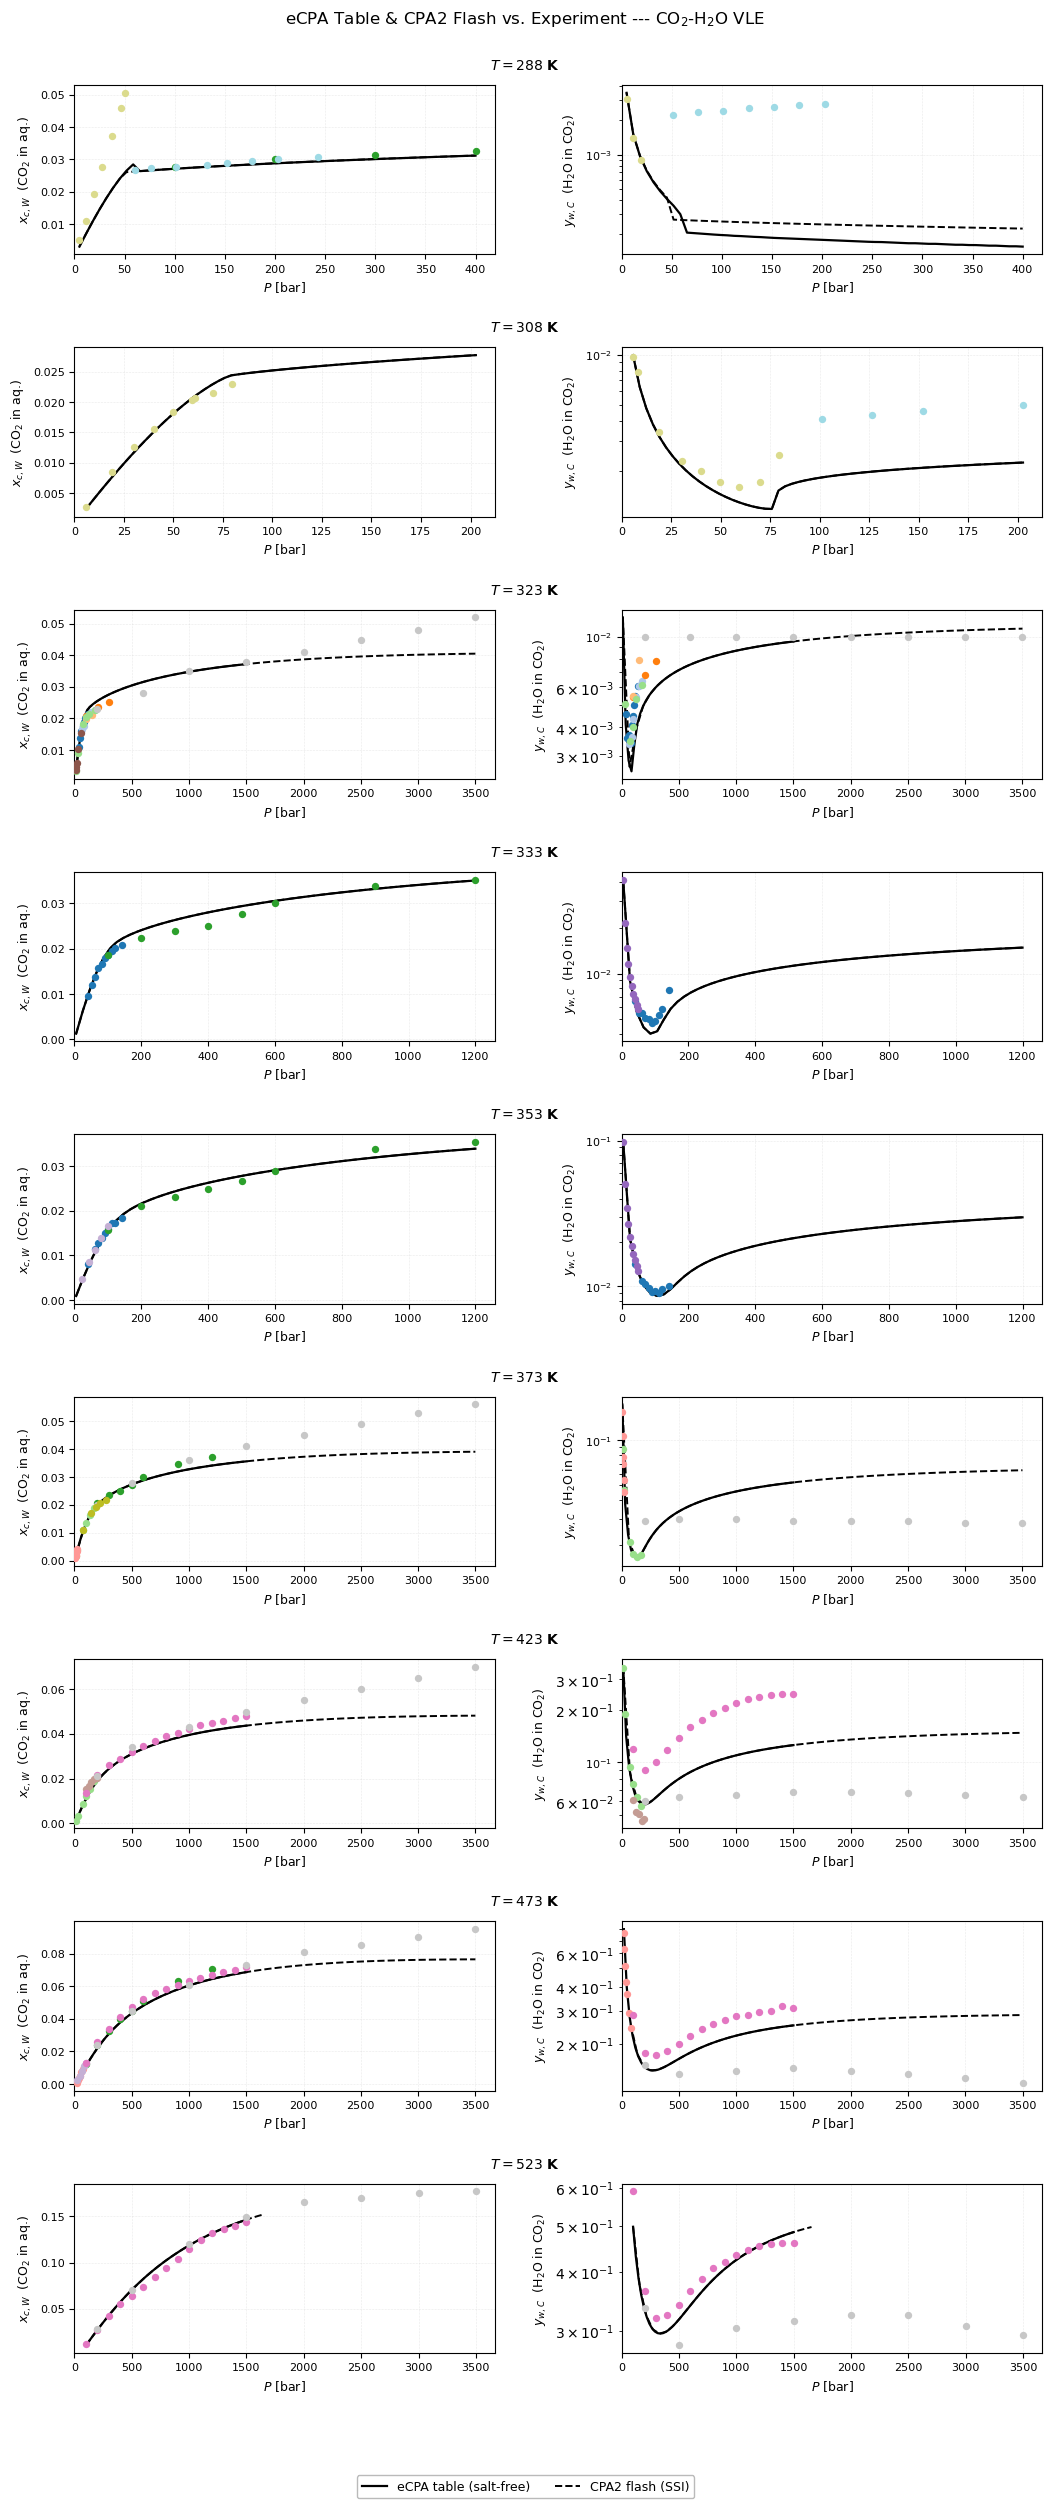

CPU times: user 6.16 s, sys: 10.7 s, total: 16.9 s
Wall time: 10.9 s


In [19]:
%time

T_SELECT = np.array(EXP_DF['T_K'].unique())
# T_SELECT = [288, 308, 323, 333, 353, 373, 423, 473, 523]

fig = plot_combined_vs_exp(
    T_list  = T_SELECT,
    N_P     = 60,
)

# fig.savefig('eCPA-CPA-Exp.png', dpi=300, bbox_inches='tight')


Much better agreement than from the CPA stability + flash, though also some large discrepancies for some temperatures.

Next, we compare several of the relevant parameters (compositions, compressibility factors Z, and association parameters Chi) from CPA versus eCPA with zero molality (from tabular data). 

CPA2 two-phase points: 1593 across 3 temperatures


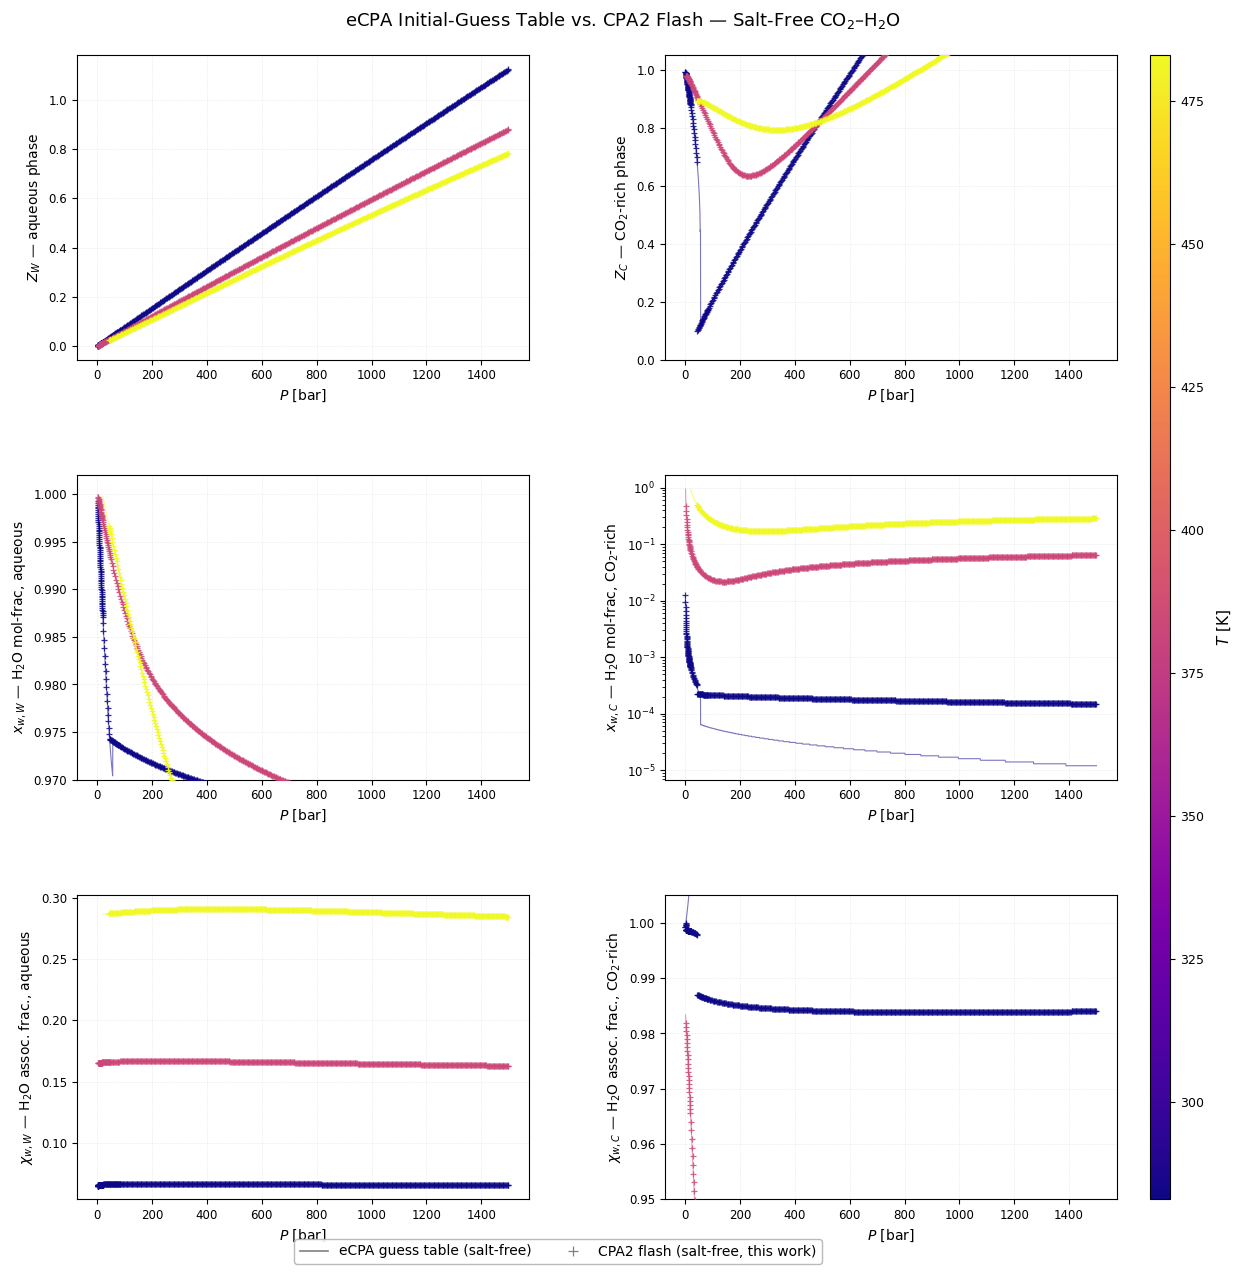

CPU times: user 3.93 s, sys: 9.17 s, total: 13.1 s
Wall time: 9.3 s


In [20]:
%%time
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.lines import Line2D

# ── Parameters ───────────────────────────────────────────────────────────────
T_STRIDE  = 100      # subsample every Nth temperature from the table
P_STRIDE  = 3      # subsample every Nth pressure point
N_WORKERS = 48
Tc4_cpa2, Tc1_cpa2   = 304.4,  647.29   # K  (eCPA param set)
Pc4_cpa2, Pc1_cpa2   = 73.8,   220.6    # bar

# ── Worker (must be top-level for pickling) ───────────────────────────────────
def _cpa2_compare_worker(args):
    import CPA2, numpy as np, warnings
    T_K, P_bar = args[0], args[1]
    nan8 = (T_K, P_bar, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out = CPA2.flash_co2_h2o_tpz(T=float(T_K), P_bar=float(P_bar), z_co2=0.5)
        if out["phase"] != "two_phase":
            return nan8
        return (T_K, P_bar,
                float(out["tie"]["Z"][0]),
                float(out["tie"]["Z"][1]),
                float(out["x"][1]),
                float(out["y"][1]),
                float(out["tie"]["chi"]["liq"][0]),
                float(out["tie"]["chi"]["vap"][0]))
    except Exception:
        return nan8

# ── Build task list and run in parallel ──────────────────────────────────────
T_all = np.array(sorted(CPA_GROUPS.keys()), dtype=float)[::T_STRIDE]

tasks = [
    (T_K, P_bar)
    for T_K in T_all
    for P_bar in CPA_GROUPS[int(T_K)]["P_bar"].to_numpy(dtype=float)[::P_STRIDE]
]

raw = {}
with ProcessPoolExecutor(max_workers=min(N_WORKERS, len(tasks))) as ex:
    futs = {ex.submit(_cpa2_compare_worker, t): t for t in tasks}
    for fut in as_completed(futs):
        T_K, P_bar, Zw, Zc, xwW, xwC, cwW, cwC = fut.result()
        raw[(T_K, P_bar)] = (Zw, Zc, xwW, xwC, cwW, cwC)

# Reshape into per-T dicts
CPA2_COMPARE = {}
_ks = ["Zw", "Zc", "xw_W", "xw_C", "chiw_W", "chiw_C"]
for T_K in T_all:
    P_arr = CPA_GROUPS[int(T_K)]["P_bar"].to_numpy(dtype=float)
    rows  = [raw.get((T_K, P), (np.nan,)*6) for P in P_arr]
    CPA2_COMPARE[T_K] = {"P": P_arr}
    for k, vals in zip(_ks, zip(*rows)):
        CPA2_COMPARE[T_K][k] = np.array(vals, dtype=float)

n_ok = sum(np.sum(np.isfinite(v["Zw"])) for v in CPA2_COMPARE.values())
print(f"CPA2 two-phase points: {n_ok} across {len(T_all)} temperatures")

# ── Plot ─────────────────────────────────────────────────────────────────────
PANELS = [
    # (table_col, cpa2_key, row, col, ylabel,                                  log,   ylim)
    ("Zw",     "Zw",     0, 0, r"$Z_W$ — aqueous phase",                      False, None),
    ("Zc",     "Zc",     0, 1, r"$Z_C$ — CO$_2$-rich phase",                  False, (0, 1.05)),
    ("xw_W",   "xw_W",   1, 0, r"$x_{w,W}$ — H$_2$O mol-frac, aqueous",      False, (0.97, 1.002)),
    ("xw_C",   "xw_C",   1, 1, r"$x_{w,C}$ — H$_2$O mol-frac, CO$_2$-rich",  True,  None),
    ("chiw_W", "chiw_W", 2, 0, r"$\chi_{w,W}$ — H$_2$O assoc. frac., aqueous", False, None),
    ("chiw_C", "chiw_C", 2, 1, r"$\chi_{w,C}$ — H$_2$O assoc. frac., CO$_2$-rich", False, (0.95, 1.005)),
]

T_min, T_max = T_all.min(), T_all.max()
cmap = cm.plasma
norm = mcolors.Normalize(vmin=T_min, vmax=T_max)

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
fig.subplots_adjust(left=0.08, right=0.88, bottom=0.06,
                    top=0.94, hspace=0.38, wspace=0.30)

for (tcol, ck, row, col, ylabel, log_y, ylim) in PANELS:
    ax = axes[row, col]
    for T_K in T_all:
        color = cmap(norm(T_K))
        dfT   = CPA_GROUPS[int(T_K)]
        P_tab = dfT["P_bar"].to_numpy(dtype=float)
        y_tab = dfT[tcol].to_numpy(dtype=float)

        # eCPA table: solid line + filled dot
        ax.plot(P_tab, y_tab, lw=0.8, color=color, alpha=0.55, zorder=1)
        # ax.scatter(P_tab, y_tab, s=5, color=color, alpha=0.80,
        #           linewidths=0, zorder=2)

        # CPA2 flash: dashed line + cross
        d    = CPA2_COMPARE[T_K]
        mask = np.isfinite(d[ck])
        if mask.any():
        #    ax.plot(d["P"][mask], d[ck][mask],
        #            lw=0.7, ls="--", color=color, alpha=0.50, zorder=3)
            ax.scatter(d["P"][mask], d[ck][mask],
                       s=22, marker="+", color=color, alpha=0.85,
                       linewidths=0.9, zorder=4)

    ax.set_xlabel(r"$P$ [bar]", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=8.5)
    ax.grid(True, ls=":", lw=0.4, alpha=0.5)
    if log_y:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(ylim)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.905, 0.06, 0.016, 0.88])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r"$T$ [K]", fontsize=11, labelpad=8)
cbar.ax.tick_params(labelsize=9)

# Legend
legend_elements = [
    Line2D([0], [0], color="grey", lw=1.2, ls="-",
           label="eCPA guess table (salt-free)"),
    Line2D([0], [0], color="grey", lw=0, ls="",
           marker="+", markersize=7, markeredgewidth=0.9,
           markeredgecolor="grey",
           label="CPA2 flash (salt-free, this work)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.45, 0.005), framealpha=0.9, edgecolor="0.7")

fig.suptitle(
    "eCPA Initial-Guess Table vs. CPA2 Flash — Salt-Free CO$_2$–H$_2$O",
    fontsize=13, y=0.975,
)

os.makedirs("results", exist_ok=True)
plt.savefig("results/table_vs_cpa2.png", dpi=150, bbox_inches="tight")
plt.show()

Again, not great agreement. Needs to be resolved.

---

## 4. The ELV Residual System

### 4.1 Overview

`ELV(x0, T, P, ms, params)` defines the **10-variable residual system** whose root gives the thermodynamic equilibrium state at fixed T, P, and aqueous molality `ms`.

The 10 unknowns are:

| Index | Variable | Description |
|-------|----------|-------------|
| 0 | `Zw` | Compressibility factor of aqueous phase |
| 1 | `x1w` | Mole fraction of H₂O in aqueous phase |
| 2 | `epsr` | Dielectric constant of aqueous phase |
| 3 | `Zc` | Compressibility factor of CO₂-rich phase |
| 4 | `x1c` | Mole fraction of H₂O in CO₂-rich phase |
| 5 | `chi1w` | Association fraction χ_A of H₂O in aqueous phase |
| 6 | `chi1c` | Association fraction χ_A of H₂O in CO₂-rich phase |
| 7 | `Ndchi1WdNw` | N · ∂χ_w/∂N_w (needed for Z_perm and fugacity) |
| 8 | `Ndchi1WdNc` | N · ∂χ_w/∂N_c |
| 9 | `Vdchi1WdV` | V · ∂χ_w/∂V |

The 10 residual equations are:

| Equation | Description |
|----------|-------------|
| f1 | Aqueous Z self-consistency: Z_aq = Z_phys + Z_assoc + Z_DH + Z_perm |
| f2 | Dielectric constant self-consistency (Kirkwood–Onsager) |
| f3 | CO₂-rich Z self-consistency: Z_c = Z_phys + Z_assoc |
| f4 | H₂O fugacity equality: ln φ₁_aq = ln φ₁_c |
| f5 | CO₂ fugacity equality: ln φ₄_aq = ln φ₄_c |
| f6 | χ_w self-consistency in aqueous phase (Wertheim) |
| f7 | χ_w self-consistency in CO₂-rich phase |
| f8–f10 | Derivatives of χ_w w.r.t. N_w, N_c, V |

The eCPA adds Debye–Hückel (DH), Born solvation, and permittivity-coupling (Perm) terms to the standard CPA equations. These are present only in the **aqueous phase**; the CO₂-rich phase has no ionic contributions.

`x0` is an initial guess for the 10 unknowns. The function computes an updated version of each variable from the eCPA physics equations, then returns the difference between the input guess and the updated value. Later/below, `fsolve` iterates `x0` until all 10 differences vanish — at which point the guessed and computed values are identical, and the system is thermodynamically self-consistent.


In [21]:
def ELV(x0, T, P, ms, params=None):
    """
    Complex-safe version of ELV for use with complex-step Jacobian.
    Changes from original:
      - x0 cast to plain array (no forced float64) so complex x0 propagates
      - _denom_sym and _rel_err use .real for scaling denominators
      - return array has no forced dtype (infers complex128 when needed)
      - T, P, ms remain real throughout (they are never perturbed)
    """

    def _denom_sym(a, b, eps=1e-30):
        return max(abs(a.real), abs(b.real), eps)          # was: max(abs(a), abs(b), eps)

    def _rel_err(a, b, scale=1.0, eps=1e-30):
        denom = max(abs(float(scale)), abs(a.real), eps)   # was: max(abs(scale), abs(a), eps)
        return (a - b) / denom

    # x0 may be complex — do NOT force float64
    x0 = np.asarray(x0)                                    # was: np.asarray(x0, dtype=np.float64)
    T  = np.float64(T)
    P  = np.float64(P)
    ms = np.float64(ms)

    _saved = None
    if params is not None:
        _saved = {}
        g = globals()
        for k, v in params.items():
            if k in g:
                _saved[k] = g[k]
            g[k] = v

    try:
        Zw, x1w, epsr, Zc, x1c, chi1w, chi1c, Ndchi1WdNw, Ndchi1WdNc, Vdchi1WdV = x0

        # PARAMETERS
        k14 = (Akij*(T/Tc4)**2 + Bkij*(T/Tc4) + Ckij)
        S14 = (ASij*(T/Tc4)**2 + BSij*(T/Tc4) + CSij)
        U4s = Uref4s + alfa4s*R*((1-T/Talfa4s)**2 - (1-Tref/Talfa4s)**2)

        # AQUEOUS PHASE
        x2w = x1w*ms*Mw
        x3w = x2w
        x4w = 1-x1w-x2w-x3w

        # Physical
        rho = P/Zw/R/T
        a1 = a01*(1 + c11*(1 - (T/Tc1)**0.5))**2
        a2 = 0
        a3 = 0
        a4 = a04*(1 + c14*(1 - (T/Tc4)**0.5))**2
        b = b1*x1w + b2*x2w + b3*x3w + b4*x4w
        U1s = Uref1s + alfa1s*R*((1-T/Talfa1s)**2 - (1-Tref/Talfa1s)**2)
        U14 = np.log(2)*(a4/b4-2*(a1*a4)**0.5*(1-k14)/(b1+b4))
        U41 = np.log(2)*(a1/b1-2*(a4*a1)**0.5*(1-k14)/(b4+b1))
        gE = 1/b*(x1w*x2w*U1s*(b1 + b2) + x1w*x3w*U1s*(b1 + b3) + x4w*x2w*U4s*(b4 + b2) + x4w*x3w*U4s*(b4 + b3) + x1w*x4w*(b1*U14 + b4*U41))
        a = b*(x1w*a1/b1 + x2w*a2/b2 + x3w*a3/b3 + x4w*a4/b4 - gE/np.log(2))
        A = a*P/R**2/T**2
        B = b*P/R/T
        A1 = a1*P/R**2/T**2
        B1 = b1*P/R/T
        B2 = b2*P/R/T
        B3 = b3*P/R/T
        A4 = a4*P/R**2/T**2
        B4 = b4*P/R/T
        Zphys = Zw/(Zw-B) - A/(Zw+B)
        lnPHI1phys = -np.log(Zw-B) + B1/B*(B/(Zw-B) - A/(Zw+B)) - np.log((Zw+B)/Zw)*(A1/B1 - 1/(B*np.log(2))*(x2w*U1s/R/T*(B1+B2) + x3w*U1s/R/T*(B1+B3) + x4w/R/T*(B1*U14+B4*U41) - B1*gE/R/T))
        lnPHI4phys = -np.log(Zw-B) + B4/B*(B/(Zw-B) - A/(Zw+B)) - np.log((Zw+B)/Zw)*(A4/B4 - 1/(B*np.log(2))*(x1w/R/T*(B1*U14+B4*U41) + x2w*U4s/R/T*(B4+B2) + x3w*U4s/R/T*(B4+B3) - B4*gE/R/T))

        # Association
        eta = B/4/Zw
        g_eta = 1/(1-1.9*eta)
        dg_deta = 1.9/(1-1.9*eta)**2
        delta = (g_eta*kappaW)*(np.exp(epsW/T) - 1)
        DELTA = delta*P/R/T
        chi4w = Zw/(Zw + 2*x1w*chi1w*S14*DELTA)
        chi1w_new = Zw/(Zw + 2*x1w*chi1w*DELTA + 2*x4w*chi4w*S14*DELTA)
        Zassoc = -2*(1 + eta/g_eta*dg_deta)*(x1w*(1-chi1w) + x4w*(1-chi4w))
        lnPHI1assoc = 4*np.log(chi1w) + B1/(8*g_eta*Zw)*dg_deta*(x1w*4*(chi1w-1) + x4w*4*(chi4w-1))
        lnPHI4assoc = 4*np.log(chi4w) + B4/(8*g_eta*Zw)*dg_deta*(x1w*4*(chi1w-1) + x4w*4*(chi4w-1))

        # DH
        xiZi = (x2w*Z2**2 + x3w*Z2**2)
        debye = (e**2*Na*rho*xiZi/(kb*T*epsr*eps0))**0.5
        X2 = 1/Sg2**3*(np.log(1+debye*Sg2) - debye*Sg2 + 0.5*(debye*Sg2)**2)
        X3 = 1/Sg3**3*(np.log(1+debye*Sg3) - debye*Sg3 + 0.5*(debye*Sg3)**2)
        lnPHI1dh = 0
        lnPHI4dh = 0
        if ms > 0:                                          # ms is real — branch is safe
            ZDH = 1/(4*np.pi*Na*rho*xiZi) * (x2w*Z2**2*(X2 - 0.5*debye**3/(1+debye*Sg2)) + x3w*Z3**2*(X3 - 0.5*debye**3/(1+debye*Sg3)))
        else:
            ZDH = 0

        # Born
        ZBorn = 0
        lnPHI1born = 0
        lnPHI4born = 0

        # Perm
        rho1 = rho*x1w
        M = Na*rho/(3*eps0)*(x1w*pol1 + x2w*pol2 + x3w*pol3 + x4w*pol4)
        eps_inf = (2*M+1)/(1-M)
        Pww = 2*rho*x1w*delta*chi1w**2
        Pwc = 2*rho*x4w*S14*delta*chi1w*chi4w
        Pw = Pww + Pwc
        gw = 1 + zww*Pww*np.cos(GAMMA1)/(Pw*np.cos(THETA1)+1)
        T1 = (2*epsr + eps_inf)*(epsr - eps_inf)/(epsr*(eps_inf + 2)**2)
        T2 = Na*rho/(9*eps0*kb*T)*(x1w*gw*dip01**2)

        dFdchiw = 1 + 2*x1w*rho*delta*chi1w**2
        dFdchic = 2*x2w*rho*S14*delta*chi4w**2
        dGdchiw = 2*x1w*rho*S14*delta*chi1w**2
        dGdchic = 1
        dFdV = -(2*rho*x1w*delta*chi1w + 2*rho*x2w*S14*delta*chi4w)*chi1w**2
        dGdV = -(2*rho*x1w*S14*delta*chi1w)*chi1w**2
        dFdNw = 2*rho*delta*chi1w**3
        dGdNw = 2*rho*S14*delta*chi1w**3
        dFdNc = 2*rho*S14*delta*chi1w**2*chi4w
        dGdNc = 0
        VddeltadV = -delta*eta*dg_deta/g_eta
        NddeltadN1 = delta*eta*b1*dg_deta/(g_eta*b)
        NddeltadN4 = delta*eta*b4*dg_deta/(g_eta*b)
        dFddelta = -chi1w**2*(1 + (delta-1)*(2*rho*x1w*chi1w + 2*rho*x4w*chi4w*S14))
        dGddelta = -chi4w**2*(1 + (delta-1)*(2*rho*x1w*chi1w*S14))
        Vdchi4WdV = -dGdchic**-1*(dGdchiw*Vdchi1WdV + dGdV + dGddelta*VddeltadV)
        Ndchi4WdNw = -dGdchic**-1*(dGdchiw*Ndchi1WdNw + dGdNw + dGddelta*NddeltadN1)
        Ndchi4WdNc = -dGdchic**-1*(dGdchiw*Ndchi1WdNc + dGdNc + dGddelta*NddeltadN4)
        Vdchi1WdV_new = -dFdchiw**-1*(dFdchic*Vdchi4WdV + dFdV + dFddelta*VddeltadV)
        Ndchi1WdNw_new = -dFdchiw**-1*(dFdchic*Ndchi4WdNw + dFdNw + dFddelta*NddeltadN1)
        Ndchi1WdNc_new = -dFdchiw**-1*(dFdchic*Ndchi4WdNc + dFdNc + dFddelta*NddeltadN4)

        dgwdPw = -(gw-1)*np.cos(THETA1)/(Pw*np.cos(THETA1)+1)
        dgwdPww = (gw-1)/Pww
        VdPwwdV = Pww*(-1 + 1/delta*VddeltadV + 2/chi1w*Vdchi1WdV)
        VdPwcdV = Pwc*(-1 + 1/delta*VddeltadV + 1/chi1w*Vdchi1WdV + 1/chi4w*Vdchi4WdV)
        NdPwwdN1 = Pww*(1/x1w + 1/(delta)*NddeltadN1 + 2/chi1w*Ndchi1WdNw)
        NdPwcdN1 = Pwc*(1/chi1w*Ndchi1WdNw + 1/(delta)*NddeltadN1 + 1/chi4w*Ndchi4WdNw)
        NdPwwdN4 = Pww*(2/chi1w*Ndchi1WdNc + 1/(delta)*NddeltadN4)
        NdPwcdN4 = Pwc*(1/x4w + 1/chi1w*Ndchi1WdNc + 1/(delta)*NddeltadN4 + 1/chi4w*Ndchi4WdNc)
        VdPwdV = VdPwwdV + VdPwcdV
        NdPwdN1 = NdPwwdN1 + NdPwcdN1
        NdPwdN4 = NdPwwdN4 + NdPwcdN4
        VdgwdV = dgwdPw*VdPwdV + dgwdPww*VdPwwdV
        NdgwdN1 = dgwdPw*NdPwdN1 + dgwdPww*NdPwwdN1
        NdgwdN4 = dgwdPw*NdPwdN4 + dgwdPww*NdPwwdN4

        dFder = (2*epsr**2 + eps_inf**2)/(epsr**2*(eps_inf + 2)**2)
        dFdeinf = (epsr*eps_inf - 4*eps_inf - 4*epsr**2 - 2*epsr)/(epsr*(eps_inf + 2)**3)
        VdeinfdV = -3*M/(1-M)**2
        NdeinfdN1 = Na*pol1*rho/(eps0*(1-M)**2)
        NdeinfdN4 = Na*pol4*rho/(eps0*(1-M)**2)
        VdFdV = Na*rho1*dip01**2/(9*eps0*kb*T)*(gw - VdgwdV)
        NdFdN1 = -Na*rho*dip01**2/(9*eps0*kb*T)*(gw + x1w*NdgwdN1)
        NdFdN4 = -Na*rho*dip01**2/(9*eps0*kb*T)*(x1w*NdgwdN4)
        VderdV = -(dFder)**-1*(dFdeinf*VdeinfdV + VdFdV)
        NderdN1 = -(dFder)**-1*(dFdeinf*NdeinfdN1 + NdFdN1)
        NderdN4 = -(dFder)**-1*(dFdeinf*NdeinfdN4 + NdFdN4)

        if ms > 0:                                          # ms is real — branch is safe
            daDHBder = debye**2/(8*np.pi*Na*rho*epsr*xiZi)*(x2w*Z2**2*(debye/(1+debye*Sg2)-1/Rb2) + x3w*Z3**2*(debye/(1+debye*Sg3)-1/Rb3))
        else:
            daDHBder = 0
        ZPerm = -daDHBder*VderdV
        lnPHI1perm = daDHBder*NderdN1
        lnPHI4perm = daDHBder*NderdN4

        # Aqueous phase totals
        Zw_new = Zphys + Zassoc + ZDH + ZBorn + ZPerm
        lnPHI1w = lnPHI1phys + lnPHI1assoc + lnPHI1dh + lnPHI1born + lnPHI1perm
        lnPHI4w = lnPHI4phys + lnPHI4assoc + lnPHI4dh + lnPHI4born + lnPHI4perm
        f1w = np.exp(lnPHI1w)*P*x1w*1e-5
        f4w = np.exp(lnPHI4w)*P*x4w*1e-5

        # CO2-RICH PHASE
        x4c = 1-x1c

        rho = P/Zc/R/T
        a1 = a01*(1 + c11*(1 - (T/Tc1)**0.5))**2
        a4 = a04*(1 + c14*(1 - (T/Tc4)**0.5))**2
        b = b1*x1c + b4*x4c
        a14 = (a1*a4)**0.5*(1-k14)
        a = x1c**2*a1 + 2*x1c*x4c*a14 + x4c**2*a4
        A = a*P/R**2/T**2
        B = b*P/R/T
        A1 = a1*P/R**2/T**2
        B1 = b1*P/R/T
        A4 = a4*P/R**2/T**2
        B4 = b4*P/R/T
        A14 = a14*P/R**2/T**2
        Zphys = Zc/(Zc-B) - A/(Zc+B)
        lnPHI1phys = -np.log(Zc-B) + B1/B*(B/(Zc-B) - A/(Zc+B)) + A/B*(B1/B - 2*(x1c*A1 + x4c*A14)/A)*np.log(1+B/Zc)
        lnPHI4phys = -np.log(Zc-B) + B4/B*(B/(Zc-B) - A/(Zc+B)) + A/B*(B4/B - 2*(x1c*A14 + x4c*A4)/A)*np.log(1+B/Zc)

        eta = B/4/Zc
        g_eta = 1/(1-1.9*eta)
        dg_deta = 1.9/(1-1.9*eta)**2
        delta = (g_eta*kappaW)*(np.exp(epsW/T) - 1)
        DELTA = delta*P/R/T
        chi4c = Zc/(Zc + 2*x1c*chi1c*S14*DELTA)
        chi1c_new = Zc/(Zc + 2*x1c*chi1c*DELTA + 2*x4c*chi4c*S14*DELTA)
        Zassoc = -2*(1 + eta/g_eta*dg_deta)*(x1c*(1-chi1c) + x4c*(1-chi4c))
        lnPHI1assoc = 4*np.log(chi1c) + B1/(8*g_eta*Zc)*dg_deta*(x1c*4*(chi1c-1) + x4c*4*(chi4c-1))
        lnPHI4assoc = 4*np.log(chi4c) + B4/(8*g_eta*Zc)*dg_deta*(x1c*4*(chi1c-1) + x4c*4*(chi4c-1))

        Zc_new = Zphys + Zassoc
        lnPHI1c = lnPHI1phys + lnPHI1assoc
        lnPHI4c = lnPHI4phys + lnPHI4assoc
        f1c = np.exp(lnPHI1c)*P*x1c*1e-5
        f4c = np.exp(lnPHI4c)*P*x4c*1e-5

        # Residuals
        f1_x  = _rel_err(Zw, Zw_new, scale=1.0)
        f2_x  = _rel_err(T1, T2, scale=1.0)
        f3_x  = _rel_err(Zc, Zc_new, scale=1.0)
        f4_x  = (f1w - f1c) / _denom_sym(f1w, f1c)
        f5_x  = (f4w - f4c) / _denom_sym(f4w, f4c)
        f6_x  = _rel_err(chi1w, chi1w_new, scale=1.0)
        f7_x  = _rel_err(chi1c, chi1c_new, scale=1.0)
        f8_x  = _rel_err(Ndchi1WdNw, Ndchi1WdNw_new, scale=1.0)
        f9_x  = _rel_err(Ndchi1WdNc, Ndchi1WdNc_new, scale=1.0)
        f10_x = _rel_err(Vdchi1WdV, Vdchi1WdV_new, scale=1.0)

        return np.array([f1_x, f2_x, f3_x, f4_x, f5_x,          # was: dtype=np.float64
                         f6_x, f7_x, f8_x, f9_x, f10_x])

    finally:
        if _saved is not None:
            g = globals()
            for k in list(params.keys()):
                if k in _saved:
                    g[k] = _saved[k]
                else:
                    del g[k]

### 4.2 Complex-Step Jacobian

The Jacobian of `ELV` — the 10×10 matrix of partial derivatives ∂fᵢ/∂xⱼ — is
required by Newton-based solvers to compute the next iterate. There are three ways
to obtain it:

1. **Analytic:** derive and code each of the 100 partial derivatives by hand.
   Fastest at runtime, but enormous implementation effort given the complexity of
   the eCPA expressions.

2. **Finite differences (default):** approximate ∂fᵢ/∂xⱼ ≈ [f(x + h·eⱼ) − f(x)] / h
   for a small real perturbation h. Simple, but suffers from **cancellation error**:
   h must be small enough to approximate the derivative, but not so small that
   floating-point subtraction loses precision. In practice, h ~ 1e-7 is a
   compromise that gives ~7 correct digits at best.

3. **Complex-step (used here):** evaluate f at a purely imaginary perturbation
   x + ih, then extract the derivative from the imaginary part:
   ∂fᵢ/∂xⱼ ≈ Im[f(x + ih·eⱼ)] / h
   Because there is no subtraction of nearly-equal numbers, h can be taken as
   small as h ~ 1e-20, giving derivatives accurate to **full machine precision**
   (~15 significant digits). The method requires only that the function be
   implemented in arithmetic that propagates complex numbers — which NumPy does
   automatically for all standard operations (`exp`, `log`, `**`, etc.).

**Implementation:** `ELV_jac` makes 10 calls to the complex-safe `ELV`, perturbing
one component of `x0` at a time by `1j * 1e-20`, and stacks the imaginary parts
into the 10×10 Jacobian. The cost is identical to finite differences (10 extra ELV
calls per Newton step), but the accuracy is orders of magnitude better — particularly
important near convergence and for ill-conditioned conditions such as high salinity
or low pressure.

**Caveat on performance:** supplying an explicit `fprime` forces a full Jacobian
recomputation at every Newton step, whereas the default `fsolve` behaviour reuses
and updates the Jacobian across steps (Powell's hybrid method). Whether the
complex-step Jacobian speeds up or slows down the overall solve depends on the
condition: for well-behaved points it may increase total ELV evaluations; for
difficult near-boundary points the improved accuracy typically reduces the number
of Newton steps enough to compensate.


In [22]:
def ELV_jac(x0, T, P, ms, params=None):
    """
    Exact Jacobian of ELV via complex-step differentiation.
    10x more accurate than finite differences, same cost (10 ELV calls).
    """
    h = 1e-20
    x0 = np.asarray(x0, dtype=complex)
    n = len(x0)
    J = np.zeros((n, n), dtype=float)
    for i in range(n):
        xp = x0.copy()
        xp[i] += 1j * h
        J[:, i] = ELV(xp, T, P, ms, params).imag / h
    return J

### 4.3 Single-Point ELV Checks

Before running the full flash or phase envelope machinery, we verify the ELV
solver directly at a few representative conditions.

Set `VERBOSE_ELV = True` to see per-iteration solver output.


In [23]:
VERBOSE_ELV = False

## 5. Flash Algorithm

### 5.1 Molality Continuation Cache

#### Why continuation is needed

The ELV system is highly nonlinear and Newton's method (`fsolve`) will only
converge if the initial guess is sufficiently close to the true solution. At
high molality (ms > 1 mol/kg), the Debye–Hückel and permittivity terms create
strong coupling between the ionic and thermodynamic variables, making a cold
start from the CPA table guess unreliable. Direct jumps to the target ms often
land outside the basin of attraction and diverge.

#### Parameter continuation along the molality axis

The solution is to approach the target molality gradually via **parameter
continuation**: we march ms from 0 to ms_max in small steps (default dm = 0.1
mol/kg), solving the ELV system at each step and using the previous converged
solution as the initial guess for the next. Because the eCPA solution varies
smoothly with ms, each step only moves the solution a small distance in the
10-dimensional state space, keeping the initial guess well within the basin of
attraction at every step.

The sequence of converged (ms, sol) pairs is stored as the **continuation
cache**. The cache is built **once per (T, P) point** before the Brent loop
begins (for full flash) — this is the dominant computational cost of a single flash calculation.

#### The Brent loop and why it needs the cache

The outer problem of the flash is to find the aqueous molality `ms_aq` that
satisfies the overall water mass balance:
```
r(ms_aq) = N_aq · x₁w + N_c · x₁c − n_H₂O_feed = 0
```

where N_aq and N_c (the molar amounts of each phase) are themselves functions
of ms_aq through the ELV solution. This is a scalar nonlinear equation in one
unknown (`ms_aq`), solved by **Brent's method** — a robust bracketing algorithm
that combines bisection, secant, and inverse quadratic interpolation steps. It
is guaranteed to converge as long as the residual has opposite signs at two
bracketing points.

Brent's method evaluates `r(ms_aq)` many times (typically 20–50 calls) during
the root search. Each evaluation requires solving the full 10-variable ELV
system at that ms. Without the cache, each of these ELV solves would need to
re-march from ms = 0 — multiplying the cost by 20–50×. With the cache, each
Brent iteration instead warm-starts from the nearest cached solution, reducing
each ELV solve to just a few Newton steps.

The overall structure of one flash call is therefore:
```
1. build_continuation_cache(ms = 0 → ms_max)   ← expensive, done once
2. brentq(water_residual, a, b)                 ← 20–50 calls to:
       └─ solve_elv(ms)                         ←   cheap warm-start solve
3. final solve_elv(ms_aq)                       ← one last clean solve
```


In [24]:
def build_continuation_cache(T, P_bar, base_guess, ms_max, params=None,
                              dm=0.1, xtol=1e-10, maxfev=2000, verbose=False):
    """
    March ms from 0 to ms_max in steps of dm, storing converged solutions.
    Returns a list of (ms, sol) pairs, in ascending ms order.

    verbose : if True, print nfev, resnorm, and wall time for every fsolve call.
    """
    import time

    cache = []
    guess = np.asarray(base_guess, dtype=np.float64)
    m = np.float64(0.0)

    def _solve_one(m, guess):
        t0 = time.perf_counter()
        sol, info, ier, mesg = fsolve(
            ELV, guess, args=(T, P_bar*1e5, m, params),
            fprime=ELV_jac if USE_COMPLEX_JAC else None,
            full_output=True, xtol=xtol, maxfev=maxfev
        )
        sol = np.asarray(sol, dtype=np.float64)
        if verbose:
            elapsed = time.perf_counter() - t0
            resnorm = float(np.linalg.norm(
                np.asarray(ELV(sol, T, P_bar*1e5, m, params), dtype=np.float64)))
            status = "OK" if ier == 1 else f"FAIL({mesg.strip()})"
            print(f"  [cache] ms={m:.3f}  ier={ier}  nfev={info['nfev']:4d}"
                  f"  njev={info['njev']:4d}  resnorm={resnorm:.2e}"
                  f"  t={elapsed*1e3:.1f}ms  {status}")
        return sol, ier

    # solve at ms=0 first
    sol, ier = _solve_one(m, guess)
    if ier == 1 and np.all(np.isfinite(sol)):
        cache.append((float(m), sol.copy()))
        guess = sol

    # march forward
    m += dm
    while m <= ms_max + 1e-12:
        sol, ier = _solve_one(m, guess)
        if ier == 1 and np.all(np.isfinite(sol)):
            cache.append((float(m), sol.copy()))
            guess = sol
        else:
            break   # stop marching if solver fails — ms_max may be too high
        m = np.float64(m + dm)

    if verbose:
        print(f"  [cache] done: {len(cache)} points, "
              f"ms = 0.000 → {cache[-1][0]:.3f}" if cache else
              f"  [cache] done: empty")

    return cache

### 5.2 ELV Solver (Robust)

`solve_elv` solves the 10-variable ELV system at a single target molality using a warm start from the continuation cache. It tries multiple perturbations of `x1c` (the H₂O content of the CO₂-rich phase) if the first attempt fails — this is the component most likely to cause convergence difficulties near the low-pressure boundary of the two-phase region.


In [25]:
def solve_elv(T, P_bar, ms_target, cache, params=None,
              xtol=1e-10, maxfev=2000, verbose=False):
    """
    Solves the 10-variable ELV system at a single target molality using a warm
    start from the continuation cache. Tries multiple perturbations of x1c if
    the first attempt fails.

    verbose : if True, print nfev, njev, resnorm, and wall time for every attempt.
    """
    import time

    T         = np.float64(T)
    P_bar     = np.float64(P_bar)
    ms_target = np.float64(ms_target)

    # find nearest cached solution as base
    ms_vals    = np.array([c[0] for c in cache])
    idx        = int(np.argmin(np.abs(ms_vals - ms_target)))
    base_guess = cache[idx][1].copy()

    x1c_multipliers = [1.0, 2.0, 5.0, 0.5, 0.1, 10.0, 0.01]

    sol = base_guess.copy()
    ier = 0
    resnorm = np.inf

    for i, mult in enumerate(x1c_multipliers):
        guess    = base_guess.copy()
        guess[4] = np.clip(base_guess[4] * mult, 1e-6, 1.0 - 1e-6)

        t0 = time.perf_counter()
        sol, info, ier, mesg = fsolve(
            ELV, guess, args=(T, P_bar*1e5, ms_target, params),
            fprime=ELV_jac if USE_COMPLEX_JAC else None,
            full_output=True, xtol=xtol, maxfev=maxfev
        )
        sol = np.asarray(sol, dtype=np.float64)

        # only compute resnorm if needed
        converged_flag = (ier == 1 and np.all(np.isfinite(sol)))
        if converged_flag or verbose:
            res     = np.asarray(ELV(sol, T, P_bar*1e5, ms_target, params),
                                 dtype=np.float64)
            resnorm = float(np.linalg.norm(res))

        if verbose:
            elapsed = (time.perf_counter() - t0) * 1e3
            status  = "OK" if (converged_flag and resnorm < 1e-6) else "fail"
            print(f"  [solve_elv] T={T:.1f}K P={P_bar:.2f}bar ms={ms_target:.3f}"
                  f"  attempt={i+1}/{len(x1c_multipliers)} mult={mult}"
                  f"  ier={ier}  nfev={info['nfev']:4d}  njev={info['njev']:4d}"
                  f"  resnorm={resnorm:.2e}  t={elapsed:.1f}ms  {status}")

        if converged_flag and resnorm < 1e-6:
            if i > 0 and verbose:
                print(f"  [solve_elv] converged on attempt {i+1} (mult={mult})")
            return sol, ier, resnorm, mesg

    # all attempts failed
    if verbose:
        print(f"  [solve_elv] ALL {len(x1c_multipliers)} attempts failed"
              f"  T={T:.1f}K P={P_bar:.2f}bar ms={ms_target:.3f}"
              f"  final resnorm={resnorm:.2e}")
    return sol, ier, resnorm, mesg

### 5.2.1 Composition vs. Pressure: eCPA vs. CPA Initial Guess

To build intuition for the eCPA corrections before running full flash calculations,
we solve the ELV system directly at a grid of conditions and plot the resulting
phase compositions as a function of pressure.

**Layout:** 3 × 3 panels — rows = temperature (333, 398, 450 K),
columns = aqueous molality (0.5, 1.0, 2.0 mol/kg).

**Each panel shows two quantities vs. P:**
- CO₂ mole fraction in the aqueous phase, $x_{\rm CO_2, aq}$ — increases with P
  as more CO₂ dissolves
- H₂O mole fraction in the CO₂-rich phase, $x_{\rm H_2O, c}$ — generally small,
  reflects water content of the supercritical phase

**Line styles:**
- **Solid** — eCPA solution at the specified molality (converged ELV root)
- **Dashed** — salt-free CPA initial guess from the table (ms = 0 proxy),
  shown for reference to make the salt correction visible

Points where the ELV solver fails to converge are silently skipped.
Solver diagnostics are printed when `VERBOSE_ELV = True`.


 T (K)    ms  P (bar)    x_CO2_aq    x_H2O_c    resnorm   nfev   t (ms)
───────────────────────────────────────────────────────────────────────────


/tmp/slurmtmp.10235237/ipykernel_2064118/2668027062.py:67: RuntimeWarning: invalid value encountered in log
  lnPHI1phys = -np.log(Zw-B) + B1/B*(B/(Zw-B) - A/(Zw+B)) - np.log((Zw+B)/Zw)*(A1/B1 - 1/(B*np.log(2))*(x2w*U1s/R/T*(B1+B2) + x3w*U1s/R/T*(B1+B3) + x4w/R/T*(B1*U14+B4*U41) - B1*gE/R/T))
/tmp/slurmtmp.10235237/ipykernel_2064118/2668027062.py:68: RuntimeWarning: invalid value encountered in log
  lnPHI4phys = -np.log(Zw-B) + B4/B*(B/(Zw-B) - A/(Zw+B)) - np.log((Zw+B)/Zw)*(A4/B4 - 1/(B*np.log(2))*(x1w/R/T*(B1*U14+B4*U41) + x2w*U4s/R/T*(B4+B2) + x3w*U4s/R/T*(B4+B3) - B4*gE/R/T))
/tmp/slurmtmp.10235237/ipykernel_2064118/2668027062.py:79: RuntimeWarning: invalid value encountered in log
  lnPHI1assoc = 4*np.log(chi1w) + B1/(8*g_eta*Zw)*dg_deta*(x1w*4*(chi1w-1) + x4w*4*(chi4w-1))
/tmp/slurmtmp.10235237/ipykernel_2064118/2668027062.py:84: RuntimeWarning: invalid value encountered in double_scalars
  debye = (e**2*Na*rho*xiZi/(kb*T*epsr*eps0))**0.5
/tmp/slurmtmp.10235237/ipykernel_2064118

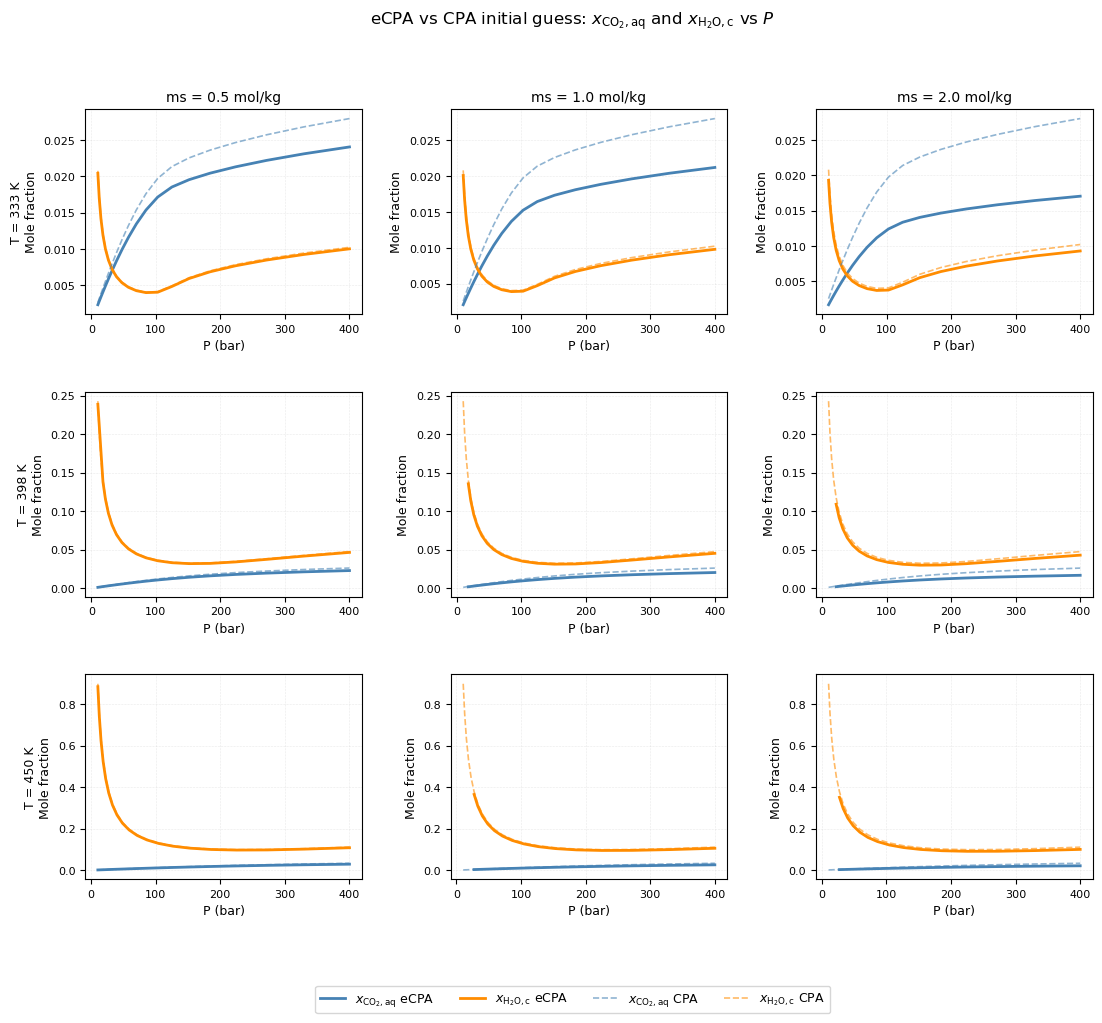

Saved → figures/elv_compositions_vs_P.png
CPU times: user 8.57 s, sys: 698 ms, total: 9.27 s
Wall time: 8.79 s


In [26]:
%%time
# ── 4.3.2  Composition vs pressure: eCPA (solid) vs CPA guess (dashed) ────
#
# 3×3 grid: rows = temperature, cols = molality
# Each panel: x_CO2_aq, x_H2O_c vs P
# Solid  = eCPA converged solution
# Dashed = CPA salt-free initial guess from table (ms=0 proxy)
# ──────────────────────────────────────────────────────────────────────────

T_vals  = [333.0, 398.0, 450.0]
ms_vals = [0.5,   1.0,   2.0  ]

# P range: use table coverage at each T as guide, log-spaced
P_min_global, P_max_global = 10.0, 400.0
N_P = 20

colors = {'x_CO2_aq': 'steelblue', 'x_H2O_c': 'darkorange'}

fig, axes = plt.subplots(3, 3, figsize=(13, 10),
                          sharex=False, sharey=False)
fig.subplots_adjust(hspace=0.38, wspace=0.32)

print(f"{'T (K)':>6s} {'ms':>5s} {'P (bar)':>8s}  "
      f"{'x_CO2_aq':>10s} {'x_H2O_c':>10s} {'resnorm':>10s} {'nfev':>6s} {'t (ms)':>8s}")
print("─" * 75)

for row, T_i in enumerate(T_vals):
    P_min_tab, P_max_tab = get_table_p_range(T_i, CPA_GROUPS, CPA_TEMPS)
    P_vals = np.logspace(
        np.log10(max(P_min_global, P_min_tab * 1.05)),
        np.log10(min(P_max_global, P_max_tab * 0.95)),
        N_P
    )

    for col, ms_i in enumerate(ms_vals):
        ax = axes[row, col]

        # storage for eCPA results
        P_conv, xCO2_aq_ecpa, xH2O_c_ecpa = [], [], []
        # storage for CPA guess (table, ms=0 proxy)
        P_all,  xCO2_aq_cpa,  xH2O_c_cpa  = [], [], []

        # build cache once for this (T, ms) pair across all P
        # (each P needs its own cache — P enters ELV explicitly)
        for P_i in P_vals:
            # ── CPA guess (table) ────────────────────────────────────────
            g = guess_table_fn(T_i, P_i)
            Zw_g, x1w_g, _, Zc_g, x1c_g = g[:5]
            x2w_g = x1w_g * 0.0 * Mw   # ms=0 for the guess
            x4w_g = 1.0 - x1w_g
            P_all.append(P_i)
            xCO2_aq_cpa.append(x4w_g)
            xH2O_c_cpa.append(x1c_g)

            # ── eCPA solution ─────────────────────────────────────────────
            try:
                base_guess = np.asarray(guess_table_fn(T_i, P_i), dtype=np.float64)
                cache = build_continuation_cache(
                    T_i, P_i, base_guess, ms_max=ms_i + 0.5,
                    params=params, dm=0.1, verbose=False
                )
                if len(cache) == 0:
                    continue

                t0 = time.perf_counter()
                sol, ier, resnorm, mesg = solve_elv(
                    T_i, P_i, ms_i, cache, params=params,
                    verbose=VERBOSE_ELV
                )
                elapsed = (time.perf_counter() - t0) * 1e3

                if ier == 1 and resnorm < 1e-6 and np.all(np.isfinite(sol)):
                    Zw, x1w, epsr, Zc, x1c = sol[:5]
                    x2w = x1w * ms_i * Mw
                    x4w = 1.0 - x1w - 2*x2w
                    x4c = 1.0 - x1c
                    P_conv.append(P_i)
                    xCO2_aq_ecpa.append(x4w)
                    xH2O_c_ecpa.append(x1c)

                    if VERBOSE_ELV:
                        print(f"{T_i:6.0f} {ms_i:5.1f} {P_i:8.1f}  "
                              f"{x4w:10.6f} {x1c:10.6f} "
                              f"{resnorm:10.2e} {'—':>6s} {elapsed:8.1f}")

            except Exception as e:
                if VERBOSE_ELV:
                    print(f"{T_i:6.0f} {ms_i:5.1f} {P_i:8.1f}  FAILED: {e}")

        # ── Plot ─────────────────────────────────────────────────────────
        P_conv      = np.array(P_conv)
        P_all       = np.array(P_all)
        xCO2_aq_ecpa = np.array(xCO2_aq_ecpa)
        xH2O_c_ecpa  = np.array(xH2O_c_ecpa)
        xCO2_aq_cpa  = np.array(xCO2_aq_cpa)
        xH2O_c_cpa   = np.array(xH2O_c_cpa)

        # eCPA solid
        if len(P_conv) > 1:
            ax.plot(P_conv, xCO2_aq_ecpa, color=colors['x_CO2_aq'],
                    lw=2.0, ls='-',  label=r'$x_{\rm CO_2,aq}$ eCPA')
            ax.plot(P_conv, xH2O_c_ecpa,  color=colors['x_H2O_c'],
                    lw=2.0, ls='-',  label=r'$x_{\rm H_2O,c}$ eCPA')

        # CPA guess dashed
        if len(P_all) > 1:
            ax.plot(P_all, xCO2_aq_cpa, color=colors['x_CO2_aq'],
                    lw=1.2, ls='--', alpha=0.6, label=r'$x_{\rm CO_2,aq}$ CPA')
            ax.plot(P_all, xH2O_c_cpa,  color=colors['x_H2O_c'],
                    lw=1.2, ls='--', alpha=0.6, label=r'$x_{\rm H_2O,c}$ CPA')

        ax.set_xlabel('P (bar)', fontsize=9)
        ax.set_ylabel('Mole fraction', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, ls=':', lw=0.4, alpha=0.5)

        if row == 0:
            ax.set_title(f'ms = {ms_i} mol/kg', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'T = {T_i:.0f} K\nMole fraction', fontsize=9)

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.03), frameon=True)

fig.suptitle(r'eCPA vs CPA initial guess: $x_{\rm CO_2,aq}$ and $x_{\rm H_2O,c}$ vs $P$',
             fontsize=12)

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/elv_compositions_vs_P.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/elv_compositions_vs_P.png")

This shows that salinity primarily affects CO2 dissolution in the aqueous phase, and more strongly at lower temperatures. 

### 5.3 Two-Phase Flash: `flash_co2_h2o_salt_1d`

Performs a closed-system two-phase flash for CO₂ + H₂O + NaCl at fixed T and P.

**Why this is not a standard flash:** Because NaCl is non-volatile, the aqueous molality `ms_aq` is not fixed — it depends on how much water partitions into each phase, which in turn depends on `ms_aq` through the dielectric constant and ionic fugacity contributions. The tie-line and material balance are **coupled** and must be solved simultaneously.

**Algorithm:**
1. Build the continuation cache from ms = 0 to ms_max (done once)
2. Define a scalar **water balance residual** `r(ms_aq)` = (predicted total water) − (feed water)
3. Scan `ms_aq` to bracket a sign change
4. Use **Brent's method** to find the root: the `ms_aq` consistent with the overall feed

**Inputs:**
- `T` (K), `P_bar` (bar): temperature and pressure
- `z_co2`: overall CO₂ mole fraction on a CO₂ + H₂O basis
- `m_tot`: overall NaCl molality relative to total water (mol/kg)
- `guess_table_fn`: function returning a 10-element initial guess at (T, P)

**Output:** dict with `ms_aq`, `N_aq`, `N_c`, `beta`, `x_aq`, `x_c`, `Z_aq`, `Z_c`, `sol`


### 5.3.1 Pseudo-Stability Pre-Check

Check from the salt-free CPA tables whether a mixture is likely to be single-phase gas/water. Because CPA2 is salt-free, this is a conservative outer bound — with salt the two-phase window only shrinks. Controlled by the `stability_check` parameter in `flash_co2_h2o_salt_1d`.

In [27]:
def _cpa2_phase_check(T, P_bar, z_co2, params):
    """
    Quick CPA2 salt-free flash to classify likely phase state.
    Returns: 'two_phase', 'single_phase_liquid', 'single_phase_gas', or 'unknown'

    Classification for single-phase results uses the CPA2 phase compositions:
    - If x_CO2 in the liquid < 0.01: essentially no CO2 dissolves → single-phase liquid
    - If x_H2O in the gas < 0.01: essentially no water evaporates → single-phase gas
    CPA2 is salt-free, so these are conservative outer bounds — with salt, the
    two-phase window only shrinks further.
    """
    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out = CPA2.flash_co2_h2o_tpz(
                T=float(T), P_bar=float(P_bar), z_co2=float(z_co2))

        if out['phase'] == 'two_phase':
            return 'two_phase'

        # Single-phase: CPA2 convention is index 0=CO2, index 1=H2O
        # out['x'] is liquid composition, out['y'] is vapour composition
        x_co2_liq = out['x'][0]   # CO2 in liquid phase
        x_h2o_vap = out['y'][1]   # H2O in vapour phase

        if x_co2_liq < 0.01:
            return 'single_phase_liquid'
        if x_h2o_vap < 0.01:
            return 'single_phase_gas'

        # compositions look two-phase-like but CPA2 said single-phase —
        # near-critical or solver edge case, don't skip the eCPA flash
        return 'unknown'

    except Exception:
        return 'unknown'

Now, define the flash algorithm, which includes checking for conditions that are likely to be single-phase.

In [28]:
def flash_co2_h2o_salt_1d(
    T, P_bar, z_co2, m_tot,
    guess_table_fn,
    params=None,
    dm=0.1,
    ms_min=1e-8,
    ms_max=20.0,
    xtol_ms=1e-10,
    elv_res_tol=1e-6,
    scan_multipliers=(0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0),
    scan_absolutes=(1.0, 2.0, 5.0, 10.0),
    verbose=False,
    stability_check=False,      # ← set True for single-point diagnostics only
):
    T     = float(T)
    P_bar = float(P_bar)
    z_co2 = float(z_co2)
    m_tot = float(m_tot)

    if not (0.0 < z_co2 < 1.0):
        raise ValueError("z_co2 must be between 0 and 1 (exclusive).")
    if m_tot < 0.0:
        raise ValueError("m_tot must be >= 0.")
    if m_tot == 0.0:
        raise NotImplementedError("m_tot=0 (salt-free) branch not implemented yet.")

    # ── optional CPA2 stability pre-check (disable for bulk scans) ────────
    if stability_check:
        _phase_hint = _cpa2_phase_check(T, P_bar, z_co2, params)
        if _phase_hint in ('single_phase_liquid', 'single_phase_gas'):
            raise RuntimeError(
                f"CPA2 salt-free pre-check indicates {_phase_hint} at "
                f"T={T:.1f}K P={P_bar:.2f}bar z_co2={z_co2:.4f}. "
                f"With salt, two-phase region only shrinks — eCPA flash skipped."
            )

    # -------------------------
    # Basis: 1 mol (CO2 + H2O)
    # -------------------------
    n_co2_tot = z_co2
    n_h2o_tot = 1.0 - z_co2
    n_salt = m_tot * n_h2o_tot * Mw

    if n_salt <= 0.0:
        raise ValueError("Computed n_salt <= 0. Check Mw units and m_tot definition.")

    # -------------------------
    # Get base guess from table
    # -------------------------
    base_guess = np.asarray(guess_table_fn(T, P_bar), dtype=np.float64)

    # -------------------------
    # Build continuation cache ONCE before Brent loop
    # -------------------------
    cache = build_continuation_cache(
        T, P_bar, base_guess, ms_max,
        params=params, dm=dm, verbose=verbose    # ← added verbose
    )

    if len(cache) == 0:
        raise RuntimeError("Continuation cache is empty — ELV failed even at ms=0.")

    if verbose:
        ms_cached = [c[0] for c in cache]
        print(f"Cache built: {len(cache)} points, ms in [{ms_cached[0]:.3f}, {ms_cached[-1]:.3f}]")

    # -------------------------
    # elv_at_ms now uses cache
    # -------------------------
    def elv_at_ms(ms):
        sol, ier, resnorm, mesg = solve_elv(
            T, P_bar, ms, cache, params=params, verbose=verbose    # ← added verbose
        )
        ok = (ier == 1) and np.isfinite(resnorm) and (resnorm <= elv_res_tol) and np.all(np.isfinite(sol))
        return ok, np.asarray(sol, dtype=np.float64), float(resnorm), mesg

    def water_residual(ms):
        ms = float(ms)
        if ms <= 0.0:
            return np.nan

        ok, sol, resnorm, mesg = elv_at_ms(ms)
        if not ok:
            return np.nan

        Zw, x1w, epsr, Zc, x1c, chi1w, chi1c, Ndchi1WdNw, Ndchi1WdNc, Vdchi1WdV = sol

        x2w = x1w * ms * Mw
        x3w = x2w
        x4w = 1.0 - x1w - x2w - x3w
        x4c = 1.0 - x1c

        if not (0.0 < x1w < 1.0 and 0.0 < x1c < 1.0):
            return np.nan
        if x2w <= 0.0 or x4c <= 0.0 or x4w <= 0.0:
            return np.nan

        N_aq = n_salt / x2w
        N_c  = (n_co2_tot - N_aq * x4w) / x4c

        if N_aq <= 0.0 or N_c <= 0.0:
            return np.nan

        return N_aq * x1w + N_c * x1c - n_h2o_tot

    # -------------------------
    # Bracketing scan
    # -------------------------
    ms_list = []
    for mult in scan_multipliers:
        ms_list.append(min(ms_max, max(ms_min, mult * m_tot)))
    for v in scan_absolutes:
        ms_list.append(min(ms_max, max(ms_min, v)))
    ms_list.append(ms_min)
    ms_list.append(ms_max)
    ms_list = sorted(set(ms_list))

    finite_scan = []
    for ms in ms_list:
        r = water_residual(ms)
        if np.isfinite(r):
            finite_scan.append((ms, float(r)))
            if verbose:
                print(f"scan ms={ms:10.6g}  residual={r: .6e}")

    if len(finite_scan) < 2:
        raise RuntimeError(
            "Could not evaluate water residual at any ms in scan. "
            "ELV likely failing for all trial ms."
        )

    a = b = fa = fb = None
    for (m1, r1), (m2, r2) in zip(finite_scan[:-1], finite_scan[1:]):
        if r1 == 0.0:
            a, fa, b, fb = m1, r1, m1, r1
            break
        if r1 * r2 < 0.0:
            a, fa, b, fb = m1, r1, m2, r2
            break

    if a is None:
        raise RuntimeError(
            "No sign change found in water residual scan. "
            "This may indicate a single-phase state at this T, P."
        )

    if verbose:
        print(f"bracket: a={a} fa={fa:.3e} | b={b} fb={fb:.3e}")

    # -------------------------
    # Brent root find
    # -------------------------
    ms_aq = float(brentq(lambda x: water_residual(x), a, b, xtol=xtol_ms))

    if ms_aq < 1e-8:
        ms_aq = 0.0

    # -------------------------
    # Final ELV at ms_aq
    # -------------------------
    ok, sol, resnorm, mesg = elv_at_ms(max(ms_aq, ms_min) if ms_aq == 0.0 else ms_aq)
    if not ok:
        raise RuntimeError(f"Final ELV failed at ms={ms_aq}: {mesg} (resnorm={resnorm})")

    Zw, x1w, epsr, Zc, x1c, *_ = sol
    x2w = x1w * ms_aq * Mw
    x3w = x2w
    x4w = 1.0 - x1w - x2w - x3w
    x4c = 1.0 - x1c

    N_aq = n_salt / x2w
    N_c  = (n_co2_tot - N_aq * x4w) / x4c

    x_aq = {"x1w": float(x1w), "x2w": float(x2w), "x3w": float(x3w), "x4w": float(x4w)}
    x_c  = {"x1c": float(x1c), "x4c": float(x4c)}

    return {
        "T": float(T), "P_bar": float(P_bar),
        "z_co2": float(z_co2), "m_tot": float(m_tot),
        "n_totals": {
            "n_co2_tot": float(z_co2),
            "n_h2o_tot": float(1.0 - z_co2),
            "n_salt_tot": float(m_tot * (1.0 - z_co2) * Mw),
        },
        "ms_aq": float(ms_aq),
        "N_aq": float(N_aq), "N_c": float(N_c),
        "beta": float(N_c / (N_aq + N_c)),
        "x_aq": x_aq, "x_c": x_c,
        "Z_aq": float(sol[0]), "Z_c": float(sol[3]),
        "sol": np.asarray(sol, dtype=np.float64),
    }

In [29]:
def flash_co2_h2o_salt_ssi(
    T, P_bar, z_co2, m_tot,
    guess_table_fn,
    params=None,
    maxiter_ms=40,
    tol_ms=1e-8,
    omega=0.7,               # SSI damping (1 = none, <1 = more conservative)
    elv_xtol=1e-10,
    elv_maxfev=2000,
    elv_res_tol=1e-6,
    verbose=False,
    stability_check=False,
):
    """
    Two-phase flash for CO2 + H2O + NaCl using folded SSI on ms_aq.

    Instead of a Brent bisection outer loop over ms_aq with a full continuation
    cache, ms_aq is updated directly from the 2x2 material balance after each
    ELV Newton solve -- no continuation, no bracketing scan.

    Algorithm
    ---------
    1. Solve ELV at ms = 0 (salt-free, table guess).
    2. Estimate initial ms_aq from the salt-free compositions via H2O/CO2
       material balance + salt balance.
    3. Iterate:
       a. Solve ELV at current ms_aq (warm-started from previous solution).
       b. Extract compositions; solve 2x2 (H2O + CO2) mass balance for N_aq, N_c.
       c. ms_aq_new = n_salt / (N_aq * x_H2O_aq * Mw)   [salt balance]
       d. Damp: ms_aq <- ms_aq + omega*(ms_aq_new - ms_aq)
       e. Stop when |delta ms_aq| < tol_ms.

    Returns the same dict structure as flash_co2_h2o_salt_1d.
    """
    T     = float(T)
    P_bar = float(P_bar)
    z_co2 = float(z_co2)
    m_tot = float(m_tot)

    if not (0.0 < z_co2 < 1.0):
        raise ValueError("z_co2 must be strictly between 0 and 1.")
    if m_tot < 0.0:
        raise ValueError("m_tot must be >= 0.")
    if m_tot == 0.0:
        raise NotImplementedError("m_tot=0 (salt-free) not implemented; use CPA2 flash.")

    if stability_check:
        hint = _cpa2_phase_check(T, P_bar, z_co2, params)
        if hint in ("single_phase_liquid", "single_phase_gas"):
            raise RuntimeError(
                f"CPA2 pre-check: {hint} at T={T:.1f}K P={P_bar:.2f}bar. "
                "Two-phase window only shrinks with salt -- eCPA flash skipped."
            )

    # ── Basis: 1 mol (CO2 + H2O) ─────────────────────────────────────────────
    n_co2_tot = z_co2
    n_h2o_tot = 1.0 - z_co2
    n_salt    = m_tot * n_h2o_tot * Mw      # mol NaCl in feed

    if n_salt <= 0.0:
        raise ValueError("n_salt <= 0. Check Mw units and m_tot.")

    # ── Internal helpers ──────────────────────────────────────────────────────
    x1c_retry_mults = [1.0, 2.0, 0.5, 5.0, 0.1, 10.0, 0.02]

    def _solve_elv(ms_aq, guess):
        """Solve 10-var ELV at ms_aq; try x1c multipliers on failure."""
        best_sol, best_rn, best_ok = guess.copy(), np.inf, False
        for mult in x1c_retry_mults:
            g = guess.copy()
            g[4] = np.clip(guess[4] * mult, 1e-6, 1.0 - 1e-6)
            sol, info, ier, mesg = fsolve(
                ELV, g, args=(T, P_bar * 1e5, ms_aq, params),
                fprime=ELV_jac if USE_COMPLEX_JAC else None,
                full_output=True, xtol=elv_xtol, maxfev=elv_maxfev,
            )
            sol = np.asarray(sol, dtype=np.float64)
            res = np.asarray(ELV(sol, T, P_bar * 1e5, ms_aq, params), dtype=np.float64)
            rn  = float(np.linalg.norm(res))
            ok  = (ier == 1) and np.all(np.isfinite(sol)) and (rn < elv_res_tol)
            if ok:
                return sol, True, rn
            if rn < best_rn:
                best_sol, best_rn, best_ok = sol.copy(), rn, ok
            if mult == 1.0 and ok:   # fast-exit on first try
                break
        return best_sol, best_ok, best_rn

    def _mass_balance(x1w, x4w, x1c, x4c):
        """
        Solve 2x2 H2O/CO2 material balance for (N_aq, N_c).
        Returns (N_aq, N_c, ms_aq_new).
        """
        det = x1w * x4c - x4w * x1c
        if abs(det) < 1e-14:
            raise ValueError(f"Degenerate phase compositions (det={det:.2e})")
        N_aq = (n_h2o_tot * x4c - n_co2_tot * x1c) / det
        N_c  = (n_co2_tot * x1w - n_h2o_tot * x4w) / det
        if N_aq <= 0.0 or N_c <= 0.0:
            raise ValueError(f"Non-physical phase amounts N_aq={N_aq:.4g} N_c={N_c:.4g}")
        ms_new = n_salt / (N_aq * x1w * Mw)
        if ms_new <= 0.0:
            raise ValueError(f"Non-physical ms_new={ms_new:.4g}")
        return float(N_aq), float(N_c), float(ms_new)

    # ── Step 0: salt-free ELV for initial ms_aq estimate ─────────────────────
    base_guess = np.asarray(guess_table_fn(T, P_bar), dtype=np.float64)
    sol0, ok0, rn0 = _solve_elv(0.0, base_guess)

    # Use salt-free compositions (ms=0 => x4w0 = 1 - x1w0, no ion terms)
    _, x1w0, _, _, x1c0, *_ = sol0
    x4w0 = 1.0 - x1w0
    x4c0 = 1.0 - x1c0

    try:
        _, _, ms_aq = _mass_balance(x1w0, x4w0, x1c0, x4c0)
        ms_aq = float(np.clip(ms_aq, m_tot * 0.5, m_tot * 100.0))
    except ValueError:
        ms_aq = m_tot   # fallback to feed molality

    if verbose:
        print(f"[SSI] ms=0 ELV ok={ok0} rn={rn0:.2e}  initial ms_aq={ms_aq:.6f}")

    guess    = sol0.copy()
    sol      = sol0.copy()
    delta    = np.inf
    converged = False

    # ── SSI loop ──────────────────────────────────────────────────────────────
    for it in range(maxiter_ms):
        sol, ok, rn = _solve_elv(ms_aq, guess)

        if not ok:
            if verbose:
                print(f"[SSI] iter {it+1}: ELV failed ms_aq={ms_aq:.6f} rn={rn:.2e}")
            break

        _, x1w, _, _, x1c, *_ = sol
        x2w = x1w * ms_aq * Mw
        x4w = 1.0 - x1w - 2.0 * x2w
        x4c = 1.0 - x1c

        if verbose:
            print(f"[SSI] iter {it+1}: ms_aq={ms_aq:.8f}  x1w={x1w:.6f}"
                  f"  x1c={x1c:.3e}  x4w={x4w:.6f}  rn={rn:.2e}")

        try:
            N_aq, N_c, ms_new = _mass_balance(x1w, x4w, x1c, x4c)
        except ValueError as e:
            if verbose:
                print(f"[SSI] iter {it+1}: mass balance failed: {e}")
            break

        # damped update
        delta  = abs(ms_new - ms_aq)
        ms_aq  = ms_aq + omega * (ms_new - ms_aq)
        guess  = sol.copy()

        if delta < tol_ms:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"SSI ms_aq did not converge in {maxiter_ms} iterations "
            f"(T={T:.1f}K P={P_bar:.2f}bar m_tot={m_tot:.4f}, last delta={delta:.2e}). "
            "Consider increasing maxiter_ms or reducing omega."
        )

    # ── Final composition bookkeeping ─────────────────────────────────────────
    _, x1w, _, _, x1c, *_ = sol
    x2w = x1w * ms_aq * Mw
    x3w = x2w
    x4w = 1.0 - x1w - 2.0 * x2w
    x4c = 1.0 - x1c
    N_aq, N_c, _ = _mass_balance(x1w, x4w, x1c, x4c)

    if verbose:
        print(f"[SSI] converged: ms_aq={ms_aq:.8f}  beta={N_c/(N_aq+N_c):.6f}"
              f"  iters={it+1}")

    return {
        "T": T, "P_bar": P_bar,
        "z_co2": z_co2, "m_tot": m_tot,
        "n_totals": {
            "n_co2_tot": n_co2_tot,
            "n_h2o_tot": n_h2o_tot,
            "n_salt_tot": n_salt,
        },
        "ms_aq": ms_aq,
        "N_aq": N_aq, "N_c": N_c,
        "beta": N_c / (N_aq + N_c),
        "x_aq": {"x1w": x1w, "x2w": x2w, "x3w": x3w, "x4w": x4w},
        "x_c":  {"x1c": x1c, "x4c": x4c},
        "Z_aq": float(sol[0]), "Z_c": float(sol[3]),
        "sol":  np.asarray(sol, dtype=np.float64),
        "n_iter_ms": it + 1,
    }


### 5.4 Flash Report Printer

Formats and prints the full flash result including phase amounts, compositions, densities, volumes, and mass balance check.


In [30]:
def print_flash_report(out):
    """
    Nicely formatted flash result summary, including:
      - molar densities (aq + CO2-rich)
      - mass densities (aq + CO2-rich)
      - phase volumes and saturations (volume fractions)

    Mole fractions, saturations, and beta printed as percentages.
    """

    # ---- Unpack state ----
    T     = float(out["T"])
    P_bar = float(out["P_bar"])
    z_co2 = float(out["z_co2"])
    m_tot = float(out["m_tot"])

    ms_aq = float(out["ms_aq"])
    N_aq  = float(out["N_aq"])
    N_c   = float(out["N_c"])
    beta  = float(out["beta"])

    x_aq  = out["x_aq"]
    x_c   = out["x_c"]
    sol   = out["sol"]

    Z_aq = float(sol[0])
    Z_c  = float(sol[3])

    # ---- Totals on basis n_CO2 + n_H2O = 1 ----
    n_co2_tot  = z_co2
    n_h2o_tot  = 1.0 - z_co2
    n_salt_tot = m_tot * n_h2o_tot * Mw

    # ---- Species moles in each phase ----
    n_h2o_a = N_aq * x_aq["x1w"]
    n_na_a  = N_aq * x_aq["x2w"]
    n_cl_a  = N_aq * x_aq["x3w"]
    n_co2_a = N_aq * x_aq["x4w"]

    n_h2o_c = N_c * x_c["x1c"]
    n_co2_c = N_c * x_c["x4c"]

    # ---- Molar densities via Z ----
    R    = 8.314462618
    P_Pa = P_bar * 1e5

    rho_mol_aq = P_Pa / (Z_aq * R * T)
    rho_mol_c  = P_Pa / (Z_c  * R * T)

    # ---- Phase-average molecular weights (kg/mol) ----
    try:
        M_H2O = float(M1);  M_NA = float(M2)
        M_CL  = float(M3);  M_CO2 = float(M4)
    except NameError:
        M_H2O = 18.01528e-3;  M_NA  = 22.98977e-3
        M_CL  = 35.453e-3;    M_CO2 = 44.0095e-3

    Mbar_aq = (x_aq["x1w"]*M_H2O + x_aq["x2w"]*M_NA +
               x_aq["x3w"]*M_CL  + x_aq["x4w"]*M_CO2)
    Mbar_c  =  x_c["x1c"]*M_H2O  + x_c["x4c"]*M_CO2

    # ---- Mass densities (kg/m^3) ----
    rho_mass_aq = rho_mol_aq * Mbar_aq
    rho_mass_c  = rho_mol_c  * Mbar_c

    # ---- Phase volumes on this basis (m^3) ----
    V_aq  = N_aq / rho_mol_aq
    V_c   = N_c  / rho_mol_c
    V_tot = V_aq + V_c

    # ---- Saturations / volume fractions ----
    S_aq = V_aq / V_tot
    S_c  = V_c  / V_tot

    # ---- Masses per phase (kg) ----
    m_aq = N_aq * Mbar_aq
    m_c  = N_c  * Mbar_c

    # ---- helpers ----
    def pct(x):  return f"{100*x:6.2f}%"
    def mol(x):  return f"{x:.4f} mol"
    def sci(x):  return f"{x:.4e}"

    # ---- Print report ----
    print("\n================ FLASH RESULT ================\n")
    print(f"  T = {T:.2f} K          P = {P_bar:.2f} bar")
    print(f"  z_CO2 (feed)  = {pct(z_co2)}    m_tot = {m_tot:.4f} mol/kg")
    print(f"  n_salt (basis)= {sci(n_salt_tot)} mol")

    print("\n-------- Phase Split --------")
    print(f"  beta  (CO2-rich fraction) = {pct(beta)}")
    print(f"  N_aq  = {sci(N_aq)} mol     N_c = {sci(N_c)} mol")

    print("\n-------- Aqueous Phase --------")
    print(f"  ms_aq = {ms_aq:.4f} mol/kg    Z_aq = {Z_aq:.6f}")
    print(f"  rho   = {rho_mass_aq:.1f} kg/m³    ({sci(rho_mol_aq)} mol/m³)")
    print(f"  V_aq  = {sci(V_aq)} m³    S_aq = {pct(S_aq)}")
    print(f"  x_H2O = {pct(x_aq['x1w'])}   x_CO2 = {pct(x_aq['x4w'])}")
    print(f"  x_Na+ = {pct(x_aq['x2w'])}   x_Cl- = {pct(x_aq['x3w'])}")
    print(f"  n_H2O = {mol(n_h2o_a)}   n_CO2 = {mol(n_co2_a)}")
    print(f"  n_Na+ = {mol(n_na_a)}   n_Cl- = {mol(n_cl_a)}")

    print("\n-------- CO2-Rich Phase --------")
    print(f"  Z_c   = {Z_c:.6f}")
    print(f"  rho   = {rho_mass_c:.1f} kg/m³    ({sci(rho_mol_c)} mol/m³)")
    print(f"  V_c   = {sci(V_c)} m³    S_c  = {pct(S_c)}")
    print(f"  x_H2O = {pct(x_c['x1c'])}   x_CO2 = {pct(x_c['x4c'])}")
    print(f"  n_H2O = {mol(n_h2o_c)}   n_CO2 = {mol(n_co2_c)}")

    print("\n-------- Mass Balance --------")
    print(f"  H2O : {sci(n_h2o_a+n_h2o_c)} mol  (target {sci(n_h2o_tot)})")
    print(f"  CO2 : {sci(n_co2_a+n_co2_c)} mol  (target {sci(n_co2_tot)})")
    print(f"  salt: {sci(n_na_a)}  mol  (target {sci(n_salt_tot)})")

    print("\n-------- Totals --------")
    print(f"  mass: {sci(m_aq)} kg (aq) + {sci(m_c)} kg (c) = {sci(m_aq+m_c)} kg")
    print(f"  vol : {sci(V_aq)} m³ (aq) + {sci(V_c)} m³ (c) = {sci(V_tot)} m³")

    print("\n=============================================\n")

### 5.5 Example Flash Calculation

Reference condition from the paper: T = 398 K, P = 100 bar, z_CO₂ = 0.5, m_NaCl = 0.5 mol/kg.


In [31]:
%%time
out_eCPA_brent = flash_co2_h2o_salt_1d(
    T=398.0,
    P_bar=100.0,
    z_co2=0.5,
    m_tot=0.5,
    guess_table_fn=guess_table_fn,
    params=params,
)
print_flash_report(out_eCPA_brent)





================ FLASH RESULT ================

  T = 398.00 K          P = 100.00 bar
  z_CO2 (feed)  =  50.00%    m_tot = 0.5000 mol/kg
  n_salt (basis)= 4.5000e-03 mol

-------- Phase Split --------
  beta  (CO2-rich fraction) =  50.88%
  N_aq  = 4.9564e-01 mol     N_c = 5.1336e-01 mol

-------- Aqueous Phase --------
  ms_aq = 0.5192 mol/kg    Z_aq = 0.060095
  rho   = 929.6 kg/m³    (5.0286e+04 mol/m³)
  V_aq  = 9.8565e-06 m³    S_aq =   6.60%
  x_H2O =  97.16%   x_CO2 =   1.03%
  x_Na+ =   0.91%   x_Cl- =   0.91%
  n_H2O = 0.4816 mol   n_CO2 = 0.0051 mol
  n_Na+ = 0.0045 mol   n_Cl- = 0.0045 mol

-------- CO2-Rich Phase --------
  Z_c   = 0.820615
  rho   = 158.6 kg/m³    (3.6825e+03 mol/m³)
  V_c   = 1.3940e-04 m³    S_c  =  93.40%
  x_H2O =   3.59%   x_CO2 =  96.41%
  n_H2O = 0.0184 mol   n_CO2 = 0.4949 mol

-------- Mass Balance --------
  H2O : 5.0000e-01 mol  (target 5.0000e-01)
  CO2 : 5.0000e-01 mol  (target 5.0000e-01)
  salt: 4.5000e-03  mol  (target 4.5000e-03)

------

In [32]:
%%time
# ── SSI version for comparison ────────────────────────────────────────────────
print("\n" + "="*60)
print("flash_co2_h2o_salt_ssi (folded SSI, no continuation):")
print("="*60)
out_ssi = flash_co2_h2o_salt_ssi(
    T=398.0,
    P_bar=100.0,
    z_co2=0.5,
    m_tot=0.5,
    guess_table_fn=guess_table_fn,
    params=params,
    verbose=True,
)
print_flash_report(out_ssi)


flash_co2_h2o_salt_ssi (folded SSI, no continuation):
[SSI] ms=0 ELV ok=True rn=8.86e-15  initial ms_aq=0.519519
[SSI] iter 1: ms_aq=0.51951879  x1w=0.971563  x1c=3.593e-02  x4w=0.010266  rn=5.94e-13
[SSI] iter 2: ms_aq=0.51926338  x1w=0.971571  x1c=3.593e-02  x4w=0.010267  rn=3.89e-16
[SSI] iter 3: ms_aq=0.51918688  x1w=0.971574  x1c=3.593e-02  x4w=0.010267  rn=1.99e-15
[SSI] iter 4: ms_aq=0.51916397  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=8.09e-15
[SSI] iter 5: ms_aq=0.51915711  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=7.89e-15
[SSI] iter 6: ms_aq=0.51915505  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=6.61e-15
[SSI] iter 7: ms_aq=0.51915444  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=5.39e-15
[SSI] iter 8: ms_aq=0.51915425  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=2.46e-15
[SSI] iter 9: ms_aq=0.51915420  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=1.87e-15
[SSI] iter 10: ms_aq=0.51915418  x1w=0.971575  x1c=3.593e-02  x4w=0.010267  rn=1.06e-15
[SSI] converged

---

## 6. Validation & Checks

### 6.1 Comparison with Salt-Free CPA2

As a limiting-case check, the eCPA solution at ms → 0 should match the salt-free CPA2 result. We compare the ms = 0 entry of the continuation cache against `CPA2.flash_tpz_two_comp` at the same (T, P).

Note that CPA2 uses component ordering CO₂ (index 0), H₂O (index 1), which is reversed from eCPA's H₂O (1), CO₂ (4) convention.


In [ ]:
%%time
# Test: eCPA at ms=0 cache entry vs CPA2 salt-free flash
T_test = 398.0
P_test = 100.0

# eCPA cache at ms=0
base_guess = guess_table_fn(T_test, P_test)
cache = build_continuation_cache(T_test, P_test, base_guess, ms_max=0.1, params=params, dm=0.05)
sol0 = cache[0][1]
Zw0, x1w0, epsr0, Zc0, x1c0 = sol0[:5]

print("eCPA at ms=0:")
print(f"  Z_aq = {Zw0:.6f}   x_H2O_aq = {x1w0:.6f}   x_CO2_aq = {1-x1w0:.6f}")
print(f"  Z_c  = {Zc0:.6f}   x_H2O_c  = {x1c0:.6f}   x_CO2_c  = {1-x1c0:.6f}")

# CPA2 salt-free flash
out_cpa2 = CPA2.flash_co2_h2o_tpz(
    T=T_test, P_bar=P_test, z_co2=0.5
)

In [ ]:
def pct_diff(a, b):
    denom = 0.5 * (abs(a) + abs(b))
    return 100.0 * (a - b) / denom if denom > 1e-30 else 0.0

print(f"{'':30s} {'eCPA ms=0':>15s} {'CPA2':>15s} {'diff %':>10s}")
print("-" * 72)
pairs = [
    ("Z_aq",     Zw0,        out_cpa2['tie']['Z'][0]),
    ("Z_c",      Zc0,        out_cpa2['tie']['Z'][1]),
    ("x_H2O_aq", x1w0,       out_cpa2['x'][1]),
    ("x_CO2_aq", 1-x1w0,     out_cpa2['x'][0]),
    ("x_H2O_c",  x1c0,       out_cpa2['y'][1]),
    ("x_CO2_c",  1-x1c0,     out_cpa2['y'][0]),
]
for label, a, b in pairs:
    print(f"{label:30s} {a:>15.6f} {b:>15.6f} {pct_diff(a,b):>9.2f}%")


### 6.2 Tie-Line Invariance Test

**Physical principle:** For a **binary** system at fixed T and P, the equilibrium
phase compositions (the tie-line) are independent of the overall feed composition —
only the phase *amounts* change via the lever rule. For a **ternary** system
(CO₂ + H₂O + NaCl), this no longer holds strictly: the tie-line is fixed only
when the aqueous molality `ms_aq` is fixed. When the input is instead `m_tot`
(salt per kg of *total feed water*), the aqueous molality varies with feed
composition because the aqueous phase fraction changes, concentrating or diluting
the salt. As a result, phase compositions will shift with z_CO₂ even at fixed T
and P — this is physical, not a numerical artifact.

**What this test actually checks:** We flash a range of feed CO₂ mole fractions
`z_co2 ∈ [0.05, 0.95]` at fixed T, P, and `m_tot`. We verify that:
- `beta` increases monotonically from ~0 (water-rich feed) to ~1 (CO₂-rich feed)
- `ms_aq` increases with z_co2, as the shrinking aqueous phase concentrates the salt
- Phase compositions (`x_H2O_aq`, `x_CO2_aq`, `x_H2O_c`, `x_CO2_c`) are nearly
  constant in the water-rich to equimolar range (z_co2 ≈ 0.05–0.75), where `ms_aq`
  stays close to `m_tot` — this is the regime where the ternary approximates binary
  behaviour
- At high z_co2 (> 0.8), `ms_aq` rises significantly and phase compositions shift
  noticeably due to salting-out — this is correct physical behaviour

**CPA2 pre-check:** Before each eCPA flash, a fast salt-free CPA2 flash is run as
a stability screen. Since salt only shrinks the two-phase window, if CPA2 predicts
single-phase, eCPA definitely will too. Feeds that fall outside the two-phase region
are labelled `single_phase_liquid` or `single_phase_gas` and skipped.


In [ ]:
def test_tieline_invariance(T, P_bar, z_co2_values, m_tot, guess_table_fn, params,
                            verbose=False):
    """
    Test tie-line invariance by flashing a range of feed compositions at fixed T, P.

    Physical setup: fixed T, P, fixed salt-to-water ratio m_tot (mol NaCl / kg total
    feed water). Feed CO2 mole fraction z_co2 varies — implicitly z_H2O = 1 - z_co2.
    Beta, ms_aq, and phase compositions are all outputs.

    At fixed T and P, the equilibrium phase compositions (tie-line) must be independent
    of z_co2. Only beta (phase split) should vary.
    """
    print(f"Tie-line invariance test: T={T} K, P={P_bar} bar, m_tot={m_tot} mol/kg")
    print(f"Varying z_co2 over {len(z_co2_values)} feed compositions\n")

    print(f"{'z_co2':>7s} {'z_H2O':>7s} {'beta':>7s} "
          f"{'x_H2O_aq':>10s} {'x_CO2_aq':>10s} {'ms_aq':>8s} "
          f"{'x_H2O_c':>9s} {'x_CO2_c':>9s} {'status':>22s}")
    print("-" * 103)

    results = []
    for z_co2 in z_co2_values:
        hint = ""  # reset each iteration
        try:
            out = flash_co2_h2o_salt_1d(
                T=T, P_bar=P_bar,
                z_co2=float(z_co2), m_tot=m_tot,
                guess_table_fn=guess_table_fn, params=params,
            )
            converged = True
            x1w  = out['x_aq']['x1w']
            x4w  = out['x_aq']['x4w']
            x1c  = out['x_c']['x1c']
            x4c  = out['x_c']['x4c']
            ms_i = out['ms_aq']
            beta = out['beta']
            hint = "converged"
        except Exception as e:
            converged = False
            x1w = x4w = x1c = x4c = ms_i = beta = np.nan
            hint = "single_phase_liquid" if "liquid" in str(e) else \
                   "single_phase_gas"    if "gas"    in str(e) else "failed"
            if verbose:
                print(f"  z_co2={z_co2:.3f} failed: {e}")

        results.append(dict(
            z_co2=z_co2, z_h2o=1-z_co2, beta=beta,
            x1w=x1w, x4w=x4w, ms_aq=ms_i,
            x1c=x1c, x4c=x4c, converged=converged, status=hint,
        ))

        nan_str = "---"
        print(f"{z_co2:7.4f} {1-z_co2:7.4f} "
              f"{beta:7.4f} " if np.isfinite(beta) else f"{'---':>7s} ",
              end="")
        print(f"{x1w:10.6f} {x4w:10.6f} {ms_i:8.4f} {x1c:9.6f} {x4c:9.6f} "
              if converged else
              f"{'---':>10s} {'---':>10s} {'---':>8s} {'---':>9s} {'---':>9s} ",
              end="")
        print(f"{hint:>22s}")

    return results

In [ ]:
%%time
results = test_tieline_invariance(
    T=398.0, P_bar=100.0,
    z_co2_values=np.array([0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]),
    m_tot=0.5,
    guess_table_fn=guess_table_fn,
    params=params,
    verbose=True,
)

---

## 7. Convergence Scan over T–P Grid


### 7.1 Helper Functions

 is defined in §2.6 alongside the other table utilities and is available throughout the notebook. It returns the min and max pressures available in the guess table at a given temperature, used here to skip conditions outside the table's P-coverage before attempting the flash.


### 7.2 Scan Loop

Runs the flash at every point on a coarse (T, P, ms, z_CO₂) grid and classifies each outcome.

**Pre-checks before each flash call:**

1. **Out-of-range filter**: if P is outside the table's coverage at this T, the condition is likely single-phase. Skip immediately.
2. **Salting-out feasibility check**: if x₄w < −0.05, the two-phase formulation has no valid solution at this (T, P, ms). Skip without calling the flash.

**Results are saved to `results/scan_results.parquet`** so the scan does not need to be rerun if the kernel is restarted. If the file already exists, it is loaded directly.

| `error_type` | Physical meaning |
|---|---|
| `none` | Converged — valid two-phase solution found |
| `out_of_range` | P outside table coverage — likely single-phase |
| `salting_out` | Salt too concentrated for CO₂ to dissolve at this P |
| `no_sign_change` | Brent cannot bracket — likely high-P miscibility |
| `elv_solver` | ELV Newton iteration stalled |
| `cache_empty` | Continuation failed even at ms = 0 |


In [ ]:
%%time

SCAN_FILE        = "results/scan_results.parquet"
USE_CPA2_PRECHECK = False   # set True to filter single-phase points before flash
os.makedirs("results", exist_ok=True)

# ── Load cached results if available ──────────────────────────────────────
if os.path.exists(SCAN_FILE):
    df_results = pd.read_parquet(SCAN_FILE)
    total  = len(df_results)
    n_conv = df_results['converged'].sum()
    print(f"Loaded cached scan results from {SCAN_FILE}")
    print(f"  {total} records | {n_conv} converged ({100*n_conv/total:.1f}%)")

else:
    # ── Grid definition ───────────────────────────────────────────────────
    T_values     = np.arange(283, 534, 25)
    P_values     = np.logspace(0, np.log10(1500), 20)
    ms_values    = [0.5, 1.0, 2.0]
    z_co2_values = np.linspace(0.1, 0.9, 5)   # 0.1, 0.3, 0.5, 0.7, 0.9

    records = []
    total = len(z_co2_values) * len(T_values) * len(P_values) * len(ms_values)
    done  = 0
    t0    = time.time()

    print(f"Running {total} flash calculations...\n")

    for z_co2 in z_co2_values:
        print(f"z_CO2 = {z_co2:.1f}")
        for T_i in T_values:
            P_min_tab, P_max_tab = get_table_p_range(float(T_i), CPA_GROUPS, CPA_TEMPS)

            for ms_i in ms_values:
                for P_i in P_values:
                    done += 1
                    record = dict(z_co2=round(z_co2, 2), T=T_i, P=round(P_i, 2), ms=ms_i,
                                  converged=False, beta=np.nan,
                                  ms_aq=np.nan, Z_aq=np.nan, Z_c=np.nan,
                                  resnorm=np.nan, error="", error_type="")

                    # filter 1: outside table P range
                    if not (P_min_tab - 1e-6 <= P_i <= P_max_tab + 1e-6):
                        record['error']      = 'outside table P range (likely single-phase)'
                        record['error_type'] = 'out_of_range'
                        records.append(record)
                        if done % 200 == 0:
                            elapsed   = time.time() - t0
                            remaining = (total - done) / (done / elapsed)
                            print(f"  {done}/{total} done | {elapsed:.0f}s elapsed | ~{remaining:.0f}s remaining")
                        continue

                    # filter 2: salting-out feasibility check
                    x1w_approx = 1.0 / (1.0 + 2.0 * ms_i * Mw)
                    x2w_approx = x1w_approx * ms_i * Mw
                    x4w_approx = 1.0 - x1w_approx - 2 * x2w_approx
                    if x4w_approx < -0.05:
                        record['error']      = (f'x4w<0 ({x4w_approx:.4f}) — '
                                                f'salting-out exceeds CO2 solubility at this P')
                        record['error_type'] = 'salting_out'
                        records.append(record)
                        if done % 200 == 0:
                            elapsed   = time.time() - t0
                            remaining = (total - done) / (done / elapsed)
                            print(f"  {done}/{total} done | {elapsed:.0f}s elapsed | ~{remaining:.0f}s remaining")
                        continue

                    # filter 3: CPA2 stability pre-check (disabled by default)
                    if USE_CPA2_PRECHECK:
                        _hint = _cpa2_phase_check(float(T_i), float(P_i), float(z_co2), params)
                        if _hint in ('single_phase_liquid', 'single_phase_gas'):
                            record['error']      = f'CPA2 pre-check: {_hint}'
                            record['error_type'] = 'out_of_range'
                            records.append(record)
                            if done % 200 == 0:
                                elapsed   = time.time() - t0
                                remaining = (total - done) / (done / elapsed)
                                print(f"  {done}/{total} done | {elapsed:.0f}s elapsed | ~{remaining:.0f}s remaining")
                            continue

                    # ── flash ─────────────────────────────────────────────
                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter("ignore", RuntimeWarning)
                            out = flash_co2_h2o_salt_1d(
                                T=float(T_i),
                                P_bar=float(P_i),
                                z_co2=float(z_co2),
                                m_tot=ms_i,
                                guess_table_fn=guess_table_fn,
                                params=params,
                            )
                        record['converged']  = True
                        record['error_type'] = 'none'
                        record['beta']       = out['beta']
                        record['ms_aq']      = out['ms_aq']
                        record['Z_aq']       = out['Z_aq']
                        record['Z_c']        = out['Z_c']

                    except RuntimeError as e:
                        msg = str(e)
                        record['error'] = msg[:80]
                        if 'sign change' in msg:
                            record['error_type'] = 'no_sign_change'
                        elif 'ELV likely failing' in msg:
                            record['error_type'] = 'elv_solver'
                        elif 'cache is empty' in msg:
                            record['error_type'] = 'cache_empty'
                        else:
                            record['error_type'] = 'runtime_other'

                    except Exception as e:
                        record['error']      = f"{type(e).__name__}: {str(e)[:60]}"
                        record['error_type'] = 'exception'

                    records.append(record)

                    if done % 200 == 0:
                        elapsed   = time.time() - t0
                        remaining = (total - done) / (done / elapsed)
                        print(f"  {done}/{total} done | {elapsed:.0f}s elapsed | ~{remaining:.0f}s remaining")

    elapsed = time.time() - t0
    print(f"\nFinished {total} calculations in {elapsed:.1f}s")

    df_results = pd.DataFrame(records)
    df_results.to_parquet(SCAN_FILE, index=False)
    print(f"Saved scan results → {SCAN_FILE}")

# ── Summary ───────────────────────────────────────────────────────────────
type_counts = df_results['error_type'].value_counts()
interp = {
    'none':           'converged successfully',
    'out_of_range':   'outside table P range or CPA2 single-phase — likely single-phase',
    'salting_out':    'salt displaces CO2 from aqueous — physically no two-phase at this ms',
    'no_sign_change': 'no sign change in water residual — likely single-phase (high-P miscibility)',
    'elv_solver':     'ELV solver failed — needs investigation',
    'cache_empty':    'continuation cache empty — ELV fails even at ms=0',
    'runtime_other':  'other runtime error',
    'exception':      'unexpected exception',
}
total = len(df_results)
print(f"\n{'Error type':<30s} {'Count':>6s} {'%':>7s}  Physical interpretation")
print("-" * 80)
for etype, count in type_counts.items():
    pct = 100 * count / total
    print(f"  {etype:<28s} {count:>6d} {pct:>6.1f}%  {interp.get(etype, '')}")

physically_expected = {'out_of_range', 'salting_out', 'no_sign_change', 'none'}
concerning = df_results[~df_results['error_type'].isin(physically_expected)]
print(f"\nGenuinely concerning failures: {len(concerning)}")
if len(concerning) > 0:
    print(concerning[['z_co2', 'T', 'P', 'ms', 'error_type', 'error']].to_string(index=False))

# expose grid variables for downstream cells (in case loaded from file)
z_co2_values = sorted(df_results['z_co2'].unique())
ms_values    = sorted(df_results['ms'].unique())
T_values     = sorted(df_results['T'].unique())

### 7.3 Convergence Map

Visualises the scan results as a grid of T–P panels (rows = z_CO₂, columns = ms), with each outcome category shaded in a distinct colour. The two-phase region (blue) is bounded by the water vapour pressure (orange/gray) at low P and the miscibility limit (red) at high P.


In [ ]:
%%time
etype_code = {
    'none':           0,
    'out_of_range':   1,
    'salting_out':    2,
    'no_sign_change': 3,
    'elv_solver':     4,
    'cache_empty':    4,
    'runtime_other':  4,
    'exception':      4,
}

shade_colors = ['steelblue', 'lightgray', 'darkorange', 'firebrick', 'red']
shade_labels = [
    'converged',
    'single-phase (out of table range)',
    'salting-out (x₄w < 0)',
    'single-phase (high-P miscibility)',
    'solver failed',
]

marker_map = {
    'none':           ('steelblue',  'o', 15),
    'out_of_range':   ('lightgray',  's', 12),
    'salting_out':    ('darkorange', '^', 15),
    'no_sign_change': ('firebrick',  'D', 15),
    'elv_solver':     ('red',        'x', 30),
    'cache_empty':    ('darkred',    'x', 30),
    'runtime_other':  ('purple',     'x', 30),
    'exception':      ('black',      'x', 30),
}

cmap = mpl.colors.ListedColormap(shade_colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm  = mpl.colors.BoundaryNorm(bounds, cmap.N)

P_grid = np.logspace(0, np.log10(1500), 300)
T_grid = np.linspace(283, 533, 300)
PP, TT = np.meshgrid(P_grid, T_grid)

n_rows = len(z_co2_values)
n_cols = len(ms_values)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 3.5*n_rows),
    sharey=True, sharex=True
)

for i, z_co2_i in enumerate(z_co2_values):
    for j, ms_i in enumerate(ms_values):
        ax = axes[i, j]

        sub = df_results[
            (np.isclose(df_results['z_co2'], round(z_co2_i, 2))) &
            (df_results['ms'] == ms_i)
        ].copy()
        sub['code'] = sub['error_type'].map(etype_code).fillna(4).astype(int)

        # shaded regions
        interp = NearestNDInterpolator(
            np.c_[np.log10(sub['P'].values), sub['T'].values],
            sub['code'].values
        )
        ZZ = interp(np.c_[np.log10(PP.ravel()), TT.ravel()]).reshape(PP.shape)
        ax.contourf(PP, TT, ZZ, levels=bounds, cmap=cmap, norm=norm, alpha=0.35)

        # scatter points
        for etype, (color, marker, size) in marker_map.items():
            grp = sub[sub['error_type'] == etype]
            if len(grp) == 0:
                continue
            ax.scatter(grp['P'], grp['T'], c=color, marker=marker,
                       s=size, zorder=3, alpha=0.9)

        ax.set_xscale('log')
        ax.grid(True, which='both', alpha=0.2)

        # row label on left
        if j == 0:
            ax.set_ylabel(f'z_CO₂ = {z_co2_i:.1f}\nT (K)', fontsize=10)

        # column label on top
        if i == 0:
            ax.set_title(f'ms = {ms_i} mol/kg', fontsize=11)

        # x label on bottom row only
        if i == n_rows - 1:
            ax.set_xlabel('P (bar)', fontsize=10)

# legend
patches = [
    mpatches.Patch(color=shade_colors[k], alpha=0.5, label=shade_labels[k])
    for k in range(len(shade_colors))
]
fig.legend(
    handles=patches,
    loc='lower center',
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
    frameon=True,
)

plt.suptitle('eCPA Flash Convergence Map', fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/ecpa_convergence_map.png", dpi=150, bbox_inches="tight")
print(f"Saved → figures/ecpa_convergence_map.png")
plt.show()

---

## 8. Phase Envelope Construction

### 8.1 Overview

The convergence scan implicitly maps the two-phase region boundaries. To extract precise phase envelopes, we use **bisection** between adjacent converged and non-converged scan points to locate the exact transition pressure at each temperature.

Two boundaries are sought:
- **Bubble point (low-P boundary)**: transition from single-phase aqueous → two-phase as P increases
- **Dew point (high-P boundary)**: transition from two-phase → single-phase (miscibility) as P increases; only detectable where the scan shows `no_sign_change` above the converged region

The **salt-free CPA2 envelope** is computed independently as a reference, using bisection directly on `CPA2.flash_tpz_two_comp`.


### 8.2 eCPA Envelope from Scan

In [ ]:
def find_envelope_from_scan(df_results, z_co2_values, ms_values, T_values,
                              guess_table_fn, params,
                              CPA_GROUPS, CPA_TEMPS,
                              n_bisect=25,
                              cache_file="results/envelope_ecpa.pkl"):

    # ── Load existing partial results ──────────────────────────────────────
    os.makedirs(os.path.dirname(cache_file), exist_ok=True)
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            envelopes = pickle.load(f)
        print(f"Resuming eCPA envelope from {cache_file}")
    else:
        envelopes = {}

    def is_two_phase(T, P, z_co2, ms):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                flash_co2_h2o_salt_1d(
                    T=float(T), P_bar=float(P),
                    z_co2=float(z_co2), m_tot=float(ms),
                    guess_table_fn=guess_table_fn, params=params,
                )
            return True
        except:
            return False

    def bisect_boundary(T, P_two, P_one, z_co2, ms, n=n_bisect):
        a, b = P_two, P_one
        for _ in range(n):
            mid = 0.5 * (a + b)
            if is_two_phase(T, mid, z_co2, ms):
                a = mid
            else:
                b = mid
            if abs(b - a) < 0.01:
                break
        return 0.5 * (a + b)

    n_z = len(z_co2_values)
    n_ms = len(ms_values)
    n_T = len(T_values)
    total = n_z * n_ms * n_T
    t_total = time.time()

    for z_idx, z_co2 in enumerate(z_co2_values):
        z_key = round(z_co2, 2)
        if z_key not in envelopes:
            envelopes[z_key] = {}

        print(f"\neCPA envelope: z_CO2 = {z_co2:.2f}  ({z_idx+1}/{n_z})")

        for ms_idx, ms in enumerate(ms_values):
            if ms not in envelopes[z_key]:
                envelopes[z_key][ms] = {}   # dict of T -> record

            existing_T = set(envelopes[z_key][ms].keys())
            remaining_T = [T for T in T_values if T not in existing_T]

            if not remaining_T:
                print(f"  ms = {ms:.1f} mol/kg — all {n_T} T-points already done, skipping")
                continue

            n_done = len(existing_T)
            print(f"  ms = {ms:.1f} mol/kg  ({ms_idx+1}/{n_ms})  "
                  f"{n_done} cached + {len(remaining_T)} remaining")
            print(f"    {'T (K)':>6s}  {'P_lo (bar)':>12s}  {'P_hi (bar)':>12s}  "
                  f"{'bisect calls':>13s}  {'time (s)':>9s}")
            print(f"    {'-'*6}  {'-'*12}  {'-'*12}  {'-'*13}  {'-'*9}")

            sub = df_results[
                (np.isclose(df_results['z_co2'], z_key)) &
                (df_results['ms'] == ms)
            ].copy()

            t_ms = time.time()
            for T in remaining_T:
                t_T = time.time()
                row_T = sub[sub['T'] == T].sort_values('P')

                if len(row_T) == 0:
                    record = dict(T=T, P_lo=np.nan, P_hi=np.nan)
                    envelopes[z_key][ms][T] = record
                    print(f"    {T:6.0f}  {'no scan data':>12s}")
                    continue

                conv = row_T[row_T['error_type'] == 'none']
                if len(conv) == 0:
                    record = dict(T=T, P_lo=np.nan, P_hi=np.nan)
                    envelopes[z_key][ms][T] = record
                    dt = time.time() - t_T
                    print(f"    {T:6.0f}  {'no converged':>12s}  {'':>12s}  {'':>13s}  {dt:9.2f}s")
                    continue

                P_conv_min = conv['P'].min()
                P_conv_max = conv['P'].max()
                n_bisect_calls = 0

                below = row_T[row_T['P'] < P_conv_min]
                if len(below) > 0:
                    P_nc_below = below['P'].max()
                    P_lo = bisect_boundary(T, P_conv_min, P_nc_below, z_co2, ms)
                    n_bisect_calls += n_bisect
                else:
                    P_lo = P_conv_min

                above = row_T[
                    (row_T['P'] > P_conv_max) &
                    (row_T['error_type'] == 'no_sign_change')
                ]
                if len(above) > 0:
                    P_nc_above = above['P'].min()
                    P_hi = bisect_boundary(T, P_conv_max, P_nc_above, z_co2, ms)
                    n_bisect_calls += n_bisect
                else:
                    P_hi = np.nan

                record = dict(T=T, P_lo=P_lo, P_hi=P_hi)
                envelopes[z_key][ms][T] = record

                # ── save after every T-point ───────────────────────────
                with open(cache_file, "wb") as f:
                    pickle.dump(envelopes, f)

                dt = time.time() - t_T
                P_hi_str = f"{P_hi:12.3f}" if np.isfinite(P_hi) else f"{'not detected':>12s}"
                done_so_far = sum(
                    len(envelopes[round(z,2)][m])
                    for z in z_co2_values if round(z,2) in envelopes
                    for m in ms_values if m in envelopes[round(z,2)]
                )
                pct = 100 * done_so_far / total
                print(f"    {T:6.0f}  {P_lo:12.3f}  {P_hi_str}  "
                      f"{n_bisect_calls:13d}  {dt:9.2f}s  [{pct:5.1f}% overall]")

            elapsed_ms = time.time() - t_ms
            print(f"  ms={ms:.1f} done in {elapsed_ms:.1f}s")

    # ── Convert inner dicts to DataFrames for plotting ─────────────────────
    envelopes_df = {}
    for z_key, ms_dict in envelopes.items():
        envelopes_df[z_key] = {}
        for ms, T_dict in ms_dict.items():
            records = list(T_dict.values())
            envelopes_df[z_key][ms] = (pd.DataFrame(records)
                                         .sort_values('T')
                                         .reset_index(drop=True))

    elapsed_total = time.time() - t_total
    print(f"\neCPA envelope complete in {elapsed_total:.1f}s")
    return envelopes_df

### 8.3 CPA2 Salt-Free Envelope

Optimized for parallel processing via `ProcessPoolExecutor`. The CPA2 envelope is salt-free and therefore independent of ms — computed once and reused across all molality panels.


#### 8.3.1 Standalone CPA2 Worker Module

The parallel workers run in subprocess processes and cannot access notebook globals. A standalone `cpa2_worker.py` module is written to disk once and imported by each worker. This cell is a no-op if the file already exists.


In [ ]:
if True:  # regenerate to use updated flash_co2_h2o_tpz
    with open("cpa2_worker.py", "w") as f:
        f.write('''\
"""
Standalone worker module for parallel CPA2 envelope computation.
Must be importable by subprocess workers -- no notebook globals allowed.
"""
import numpy as np
import warnings
import CPA2


def _cpa2_flash(T, P, z_co2, maxiter=100):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter(\'ignore\')
            out = CPA2.flash_co2_h2o_tpz(
                T=float(T), P_bar=float(P), z_co2=float(z_co2))
        return out
    except:
        return None

def _is_two_phase(T, P, z_co2, maxiter=100):
    out = _cpa2_flash(T, P, z_co2, maxiter=maxiter)
    return out is not None and out[\'phase\'] == \'two_phase\'

def _bisect(T, P_two, P_one, z_co2, n=10):
    a, b = min(P_two, P_one), max(P_two, P_one)
    if not _is_two_phase(T, a, z_co2, maxiter=200):
        a, b = b, a
    for _ in range(n):
        mid = 0.5 * (a + b)
        if _is_two_phase(T, mid, z_co2, maxiter=200):
            a = mid
        else:
            b = mid
        if abs(b - a) < 0.1:
            break
    return 0.5 * (a + b)

def compute_one_point(args):
    """
    Compute the phase boundary for a single (T, z_co2) point.
    args = (T, z_co2, P_scan)
    Returns dict with keys: T, z_co2, P_lo, P_hi
    """
    T, z_co2, P_scan = args
    P_scan = np.array(P_scan)

    two_phase_Ps = [P for P in P_scan if _is_two_phase(T, P, z_co2)]

    if not two_phase_Ps:
        return dict(T=T, z_co2=z_co2, P_lo=np.nan, P_hi=np.nan)

    P_first = min(two_phase_Ps)
    P_last  = max(two_phase_Ps)

    idx_first = np.searchsorted(P_scan, P_first)
    P_lo = (P_first if idx_first == 0
            else _bisect(T, P_first, P_scan[idx_first - 1], z_co2))

    idx_last = np.searchsorted(P_scan, P_last)
    if idx_last >= len(P_scan) - 1:
        P_hi = np.nan
    else:
        P_above = P_scan[idx_last + 1]
        P_hi = (_bisect(T, P_last, P_above, z_co2)
                if not _is_two_phase(T, P_above, z_co2)
                else np.nan)

    return dict(T=T, z_co2=z_co2, P_lo=P_lo, P_hi=P_hi)
''')
    print("Created cpa2_worker.py")


In [ ]:
def build_cpa2_envelope(T_values, z_co2_values, params_cpa2,
                         n_workers=48,
                         cache_file="results/envelope_cpa2.pkl"):

    import cpa2_worker

    os.makedirs(os.path.dirname(cache_file), exist_ok=True)

    # ── Load existing partial results ──────────────────────────────────────
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            envelopes = pickle.load(f)
        n_cached = sum(len(v) for v in envelopes.values())
        print(f"Resuming CPA2 envelope from {cache_file}  ({n_cached} points cached)")
    else:
        envelopes = {}

    P_scan = list(np.logspace(0, np.log10(1500), 20))

    # ── Build list of remaining (T, z_co2) tasks ───────────────────────────
    all_tasks = []
    for z_co2 in z_co2_values:
        z_key = round(z_co2, 2)
        done_T = set(envelopes.get(z_key, {}).keys())
        for T in T_values:
            if T not in done_T:
                all_tasks.append((float(T), float(z_co2), P_scan))

    total = len(T_values) * len(z_co2_values)
    n_cached = total - len(all_tasks)
    print(f"Total points: {total}  |  cached: {n_cached}  |  remaining: {len(all_tasks)}")

    if not all_tasks:
        print("All points already computed.")
    else:
        n_workers_use = min(n_workers, len(all_tasks))
        print(f"Launching {n_workers_use} parallel workers...\n")
        print(f"  {'z_CO2':>7s}  {'T (K)':>6s}  {'P_lo (bar)':>12s}  "
              f"{'P_hi (bar)':>12s}  {'elapsed':>9s}  {'done':>10s}")
        print(f"  {'-'*7}  {'-'*6}  {'-'*12}  {'-'*12}  {'-'*9}  {'-'*10}")

        t_start = time.time()
        completed = 0

        with ProcessPoolExecutor(max_workers=n_workers_use) as executor:
            futures = {executor.submit(cpa2_worker.compute_one_point, task): task
                       for task in all_tasks}

            for future in as_completed(futures):
                result = future.result()
                T      = result['T']
                z_co2  = result['z_co2']
                P_lo   = result['P_lo']
                P_hi   = result['P_hi']
                z_key  = round(z_co2, 2)

                if z_key not in envelopes:
                    envelopes[z_key] = {}
                envelopes[z_key][T] = dict(T=T, P_lo=P_lo, P_hi=P_hi)

                # save after every completed result
                with open(cache_file, "wb") as f:
                    pickle.dump(envelopes, f)

                completed += 1
                elapsed = time.time() - t_start
                done_total = n_cached + completed
                P_hi_str = f"{P_hi:12.3f}" if np.isfinite(P_hi) else f"{'> scan range':>12s}"
                print(f"  {z_co2:7.2f}  {T:6.0f}  {P_lo:12.3f}  {P_hi_str}  "
                      f"{elapsed:8.1f}s  {done_total:4d}/{total:4d}")

        elapsed_total = time.time() - t_start
        rate = len(all_tasks) / elapsed_total if elapsed_total > 0 else 0
        print(f"\nParallel run complete: {len(all_tasks)} points in "
              f"{elapsed_total:.1f}s  ({rate:.1f} points/s, "
              f"effective speedup vs serial: ~{n_workers_use}x)")

    # ── Convert to DataFrames ──────────────────────────────────────────────
    envelopes_df = {}
    for z_key, T_dict in envelopes.items():
        records = list(T_dict.values())
        envelopes_df[z_key] = (pd.DataFrame(records)
                                 .sort_values('T')
                                 .reset_index(drop=True))
    return envelopes_df

### 8.4 Run Envelope Builders

In [ ]:
%%time
os.makedirs("results", exist_ok=True)

ECPA_FILE = "results/envelope_ecpa.pkl"
CPA2_FILE = "results/envelope_cpa2.pkl"

T_envelope_cpa2 = np.arange(283, 534, 25)   # 11 T-points
T_envelope_ecpa = T_values                   # reuse scan T grid

# ── eCPA envelopes ─────────────────────────────────────────────────────────
print("=" * 60)
print("eCPA phase envelopes")
print("=" * 60)
t0 = time.time()
envelopes_ecpa = find_envelope_from_scan(
    df_results, z_co2_values, ms_values, T_envelope_ecpa,
    guess_table_fn, params,
    CPA_GROUPS, CPA_TEMPS,
    cache_file=ECPA_FILE,
)
print(f"eCPA total time this run: {time.time()-t0:.1f}s")



In [ ]:
%%time
print("\n" + "=" * 60)
print("CPA2 salt-free phase envelopes (parallel)")
print(f"  T grid: {T_envelope_cpa2[0]:.0f}–{T_envelope_cpa2[-1]:.0f} K  "
      f"({len(T_envelope_cpa2)} points)")
print(f"  z_CO2: {[round(z,2) for z in z_co2_values]}")
print("=" * 60)
t0 = time.time()
envelopes_cpa2 = build_cpa2_envelope(
    T_envelope_cpa2, z_co2_values, params,
    n_workers=48,
    cache_file=CPA2_FILE,
)
print(f"CPA2 total time this run: {time.time()-t0:.1f}s")

In [ ]:
%%time

ENVELOPE_FILE = "results/envelopes.pkl"
os.makedirs("results", exist_ok=True)

# CPA2 is salt-free — envelope is independent of ms, computed once
T_envelope_cpa2 = np.arange(283, 534, 25)   # 11 T-points, fast
T_envelope_ecpa = T_values                   # reuse scan T grid

# ── Load cached envelopes if available ────────────────────────────────────
if os.path.exists(ENVELOPE_FILE):
    with open(ENVELOPE_FILE, "rb") as f:
        saved = pickle.load(f)
    envelopes_ecpa = saved["envelopes_ecpa"]
    envelopes_cpa2 = saved["envelopes_cpa2"]
    print(f"Loaded cached envelopes from {ENVELOPE_FILE}")
    print(f"  eCPA: z_co2 values = {list(envelopes_ecpa.keys())}")
    print(f"  CPA2: z_co2 values = {list(envelopes_cpa2.keys())}")

else:
    # ── eCPA envelopes ────────────────────────────────────────────────────
    t0 = time.time()
    print("=" * 60)
    print("Building eCPA phase envelopes (bisection on scan results)")
    print("=" * 60)
    envelopes_ecpa = find_envelope_from_scan(
        df_results, z_co2_values, ms_values, T_envelope_ecpa,
        guess_table_fn, params,
        CPA_GROUPS, CPA_TEMPS,
 #       verbose=False,
    )
    print(f"\neCPA total time: {time.time()-t0:.1f}s")

    # ── CPA2 envelope (salt-free, computed ONCE — independent of ms) ──────
    t0 = time.time()
    print("\n" + "=" * 60)
    print("Building CPA2 salt-free phase envelopes")
    print(f"  T grid: {T_envelope_cpa2[0]:.0f}–{T_envelope_cpa2[-1]:.0f} K "
          f"({len(T_envelope_cpa2)} points)")
    print(f"  z_CO2 values: {[round(z,2) for z in z_co2_values]}")
    print("=" * 60)
    envelopes_cpa2 = build_cpa2_envelope(
        T_envelope_cpa2, z_co2_values, params,
#        verbose=True,
    )
    print(f"\nCPA2 total time: {time.time()-t0:.1f}s")

    # ── Save ──────────────────────────────────────────────────────────────
    with open(ENVELOPE_FILE, "wb") as f:
        pickle.dump({"envelopes_ecpa": envelopes_ecpa,
                     "envelopes_cpa2": envelopes_cpa2}, f)
    print(f"\nSaved envelopes → {ENVELOPE_FILE}")

### 8.5 Phase Envelope Plot

Each panel shows the two-phase boundaries for one (z_CO₂, ms) combination. The black dotted/dash-dot curves show the salt-free CPA2 reference envelope — the salting-out effect shifts the eCPA bubble point to higher pressures and shrinks the two-phase window as ms increases.


In [ ]:
%%time
n_rows = len(z_co2_values)
n_cols = len(ms_values)
ms_colors = ['steelblue', 'darkorange', 'firebrick']

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 3.5*n_rows),
    sharey=True, sharex=True
)

# CPA2 may not be available yet — load from cache file if possible
_cpa2_available = False
if 'envelopes_cpa2' in dir() and envelopes_cpa2:
    _cpa2_available = True
elif os.path.exists("results/envelope_cpa2.pkl"):
    with open("results/envelope_cpa2.pkl", "rb") as f:
        _partial = pickle.load(f)
    # convert partial dict-of-dicts to DataFrames
    envelopes_cpa2 = {}
    for z_key, T_dict in _partial.items():
        records = list(T_dict.values())
        if records:
            envelopes_cpa2[z_key] = (pd.DataFrame(records)
                                       .sort_values('T')
                                       .reset_index(drop=True))
    _cpa2_available = bool(envelopes_cpa2)
    print(f"Loaded partial CPA2 results: "
          f"{sum(len(v) for v in _partial.values())} points across "
          f"{len(_partial)} z_CO2 values")

if not _cpa2_available:
    print("CPA2 envelope not yet available — plotting eCPA only")

for i, z_co2_i in enumerate(z_co2_values):
    z_key = round(z_co2_i, 2)

    df_cpa2 = (envelopes_cpa2.get(z_key, pd.DataFrame())
               if _cpa2_available else pd.DataFrame())

    for j, ms_i in enumerate(ms_values):
        ax = axes[i, j]

        # --- eCPA envelope ---
        df_env = envelopes_ecpa[z_key][ms_i].dropna(subset=['P_lo'])
        if len(df_env) > 0:
            T_plot = df_env['T'].values
            P_lo   = df_env['P_lo'].values
            ax.plot(T_plot, P_lo, color=ms_colors[j], lw=2,
                    label='bubble point (eCPA)')
            hi_mask = np.isfinite(df_env['P_hi'].values)
            if hi_mask.any():
                ax.plot(T_plot[hi_mask], df_env['P_hi'].values[hi_mask],
                        color=ms_colors[j], lw=2, ls='--',
                        label='dew point (eCPA)')
                T_fill = np.concatenate([T_plot[hi_mask], T_plot[hi_mask][::-1]])
                P_fill = np.concatenate([df_env['P_hi'].values[hi_mask],
                                         P_lo[hi_mask][::-1]])
                ax.fill(T_fill, P_fill, color=ms_colors[j], alpha=0.12)

        # --- CPA2 envelope (only if available for this z_co2) ---
        if _cpa2_available and len(df_cpa2) > 0:
            df_c2_lo = df_cpa2.dropna(subset=['P_lo'])
            if len(df_c2_lo) > 0:
                ax.plot(df_c2_lo['T'], df_c2_lo['P_lo'], color='black',
                        lw=1.5, ls=':', label='bubble point (CPA2, salt-free)')
            df_c2_hi = df_cpa2.dropna(subset=['P_hi'])
            if len(df_c2_hi) > 0:
                ax.plot(df_c2_hi['T'], df_c2_hi['P_hi'], color='black',
                        lw=1.5, ls='-.', label='dew point (CPA2, salt-free)')

        ax.set_yscale('log')
        ax.set_xlim(283, 533)
        ax.grid(True, which='both', alpha=0.2)
        if j == 0:
            ax.set_ylabel(f'z_CO₂={z_co2_i:.1f}\nP (bar)', fontsize=10)
        if i == 0:
            ax.set_title(f'ms = {ms_i} mol/kg', fontsize=11)
        if i == n_rows - 1:
            ax.set_xlabel('T (K)', fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
seen = dict(zip(labels, handles))
fig.legend(
    seen.values(), seen.keys(),
    loc='lower center', ncol=4,
    fontsize=10, bbox_to_anchor=(0.5, -0.04),
    frameon=True,
)

cpa2_status = (f"{sum(len(v) for v in _partial.values())} pts"
               if _cpa2_available and '_partial' in dir()
               else ("complete" if _cpa2_available else "pending"))
plt.suptitle(f'CO₂ – H₂O – NaCl Phase Envelope (eCPA EoS) | CPA2: {cpa2_status}',
             fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/ecpa_phase_envelope.png", dpi=150, bbox_inches="tight")
print("Saved → figures/ecpa_phase_envelope.png")
plt.show()

---

## 9. Diagnostics: Investigating Challenging Conditions

### 9.1 Background

At low pressures (below ~10–20 bar depending on T) and moderate-to-high salinity, the flash fails with "ELV likely failing for all ms". Investigation reveals this is a **physical constraint** rather than a numerical bug: at low pressure, the CO₂ partial pressure is small, so CO₂ dissolved in the aqueous phase is very dilute. When NaCl is added at ms = 0.5 mol/kg, the ion mole fractions (x₂w, x₃w) consume so much of the aqueous phase composition that `x₄w = 1 − x₁w − x₂w − x₃w` goes **negative** — physically impossible. The salting-out effect exceeds the CO₂ solubility at that pressure.

The diagnostic cells below verify this interpretation.


### 9.2 Four-Way Test at a Failing Condition (T=308 K, P=4.66 bar)

Tests the same condition four ways to isolate the failure mechanism:
1. eCPA flash at ms = 0.5 (expected to fail)
2. eCPA flash at ms = 1×10⁻⁴ (should converge — confirms two-phase region exists)
3. CPA2 salt-free flash (independent confirmation of two-phase)
4. eCPA flash seeded from CPA2 result at ms = 0.5 (tests whether better guess helps)


In [ ]:
%%time
T_test = 308.0
P_test = 4.66

# ── 1. eCPA flash at the failing molality ──────────────────────────────────
print("=" * 60)
print(f"TEST 1: eCPA flash  T={T_test}K  P={P_test}bar  ms=0.5")
print("=" * 60)
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        out1 = flash_co2_h2o_salt_1d(
            T=T_test, P_bar=P_test, z_co2=0.5, m_tot=0.5,
            guess_table_fn=guess_table_fn, params=params,
        )
    print("CONVERGED")
    print_flash_report(out1)
except Exception as e:
    print(f"FAILED: {e}")

# ── 2. eCPA flash at near-zero molality ───────────────────────────────────
print("\n" + "=" * 60)
print(f"TEST 2: eCPA flash  T={T_test}K  P={P_test}bar  ms=1e-4")
print("=" * 60)
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        out2 = flash_co2_h2o_salt_1d(
            T=T_test, P_bar=P_test, z_co2=0.5, m_tot=1e-4,
            guess_table_fn=guess_table_fn, params=params,
        )
    print("CONVERGED")
    print_flash_report(out2)
except Exception as e:
    print(f"FAILED: {e}")

# ── 3. CPA2 salt-free flash ────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"TEST 3: CPA2 salt-free flash  T={T_test}K  P={P_test}bar")
print("=" * 60)
try:
    out3 = CPA2.flash_co2_h2o_tpz(
        T=T_test, P_bar=P_test, z_co2=0.5
    )
    print(f"phase: {out3['phase']}  beta: {out3['beta']:.6f}")
    if out3['phase'] == 'two_phase':
        print(f"x(liq) = {out3['x']}")
        print(f"y(vap) = {out3['y']}")
        print(f"Z(liq,vap) = {out3['tie']['Z']}")
        print(f"K = {out3['tie']['K']}")
    else:
        print("Single phase — no two-phase split found")
except Exception as e:
    print(f"FAILED: {e}")

# ── 4. Use CPA2 result as initial guess for eCPA ──────────────────────────
print("\n" + "=" * 60)
print(f"TEST 4: eCPA flash with CPA2-derived initial guess  ms=0.5")
print("=" * 60)
try:
    # build a guess vector from CPA2 result
    # CPA2 convention: index 0=CO2, index 1=H2O
    if out3['phase'] == 'two_phase':
        Z_liq, Z_vap = out3['tie']['Z']
        x_h2o_liq = out3['x'][1]   # water in liquid
        x_h2o_vap = out3['y'][1]   # water in vapor

        # current table guess for chi and derivative values
        table_guess = guess_table_fn(T_test, P_test)

        # override Z and composition entries, keep chi/derivative entries
        cpa2_guess = table_guess.copy()
        cpa2_guess[0] = Z_liq        # Zw
        cpa2_guess[1] = x_h2o_liq   # x1w
        cpa2_guess[3] = Z_vap        # Zc
        cpa2_guess[4] = x_h2o_vap   # x1c
        # leave epsr, chi, derivatives from table

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)

            # build a fresh cache seeded from this guess
            cache_cpa2 = build_continuation_cache(
                T_test, P_test, cpa2_guess,
                ms_max=0.6, params=params, dm=0.1
            )
            if len(cache_cpa2) == 0:
                print("Cache empty with CPA2 guess")
            else:
                sol, ier, resnorm, mesg = solve_elv(
                    T_test, P_test, 0.5, cache_cpa2, params=params
                )
                print(f"ier={ier}  resnorm={resnorm:.3e}")
                if ier == 1 and resnorm < 1e-6:
                    print("CONVERGED with CPA2-seeded guess")
                    Zw, x1w, epsr, Zc, x1c = sol[:5]
                    print(f"  Zw={Zw:.6f}  x1w={x1w:.6f}  Zc={Zc:.6f}  x1c={x1c:.6f}")
                else:
                    print(f"Still failed: {mesg}")
except Exception as e:
    print(f"FAILED: {e}")

### 9.3 Composition Feasibility Inspection

Directly computes `x₄w` (aqueous CO₂ mole fraction) at the failing condition using the ms = 1×10⁻⁴ converged solution as a proxy for the aqueous phase structure. Confirms the negative-x₄w diagnosis.


In [ ]:
%%time
# Evaluate ELV at the near-converged CPA2-seeded point 
# and inspect individual term contributions
T_test, P_test, ms_test = 308.0, 4.66, 0.5

# use the ms=1e-4 converged solution as starting point
sol_nearzero = out2['sol']

# manually evaluate key intermediate quantities at ms=0.5
Zw, x1w, epsr, Zc, x1c = sol_nearzero[:5]
x2w = x1w * ms_test * Mw
x3w = x2w
x4w = 1 - x1w - x2w - x3w

rho = (P_test*1e5) / Zw / R / T_test
xiZi = (x2w * 1**2 + x3w * 1**2)
debye = (e**2 * Na * rho * xiZi / (kb * T_test * epsr * eps0))**0.5

print(f"x1w={x1w:.6f}  x2w={x2w:.6f}  x4w={x4w:.6f}")
print(f"rho = {rho:.4e} mol/m3")
print(f"ionic strength proxy xiZi = {xiZi:.6e}")
print(f"Debye length 1/kappa = {1/debye*1e10:.4f} Angstrom")
print(f"Debye kappa*Sg2 = {debye*Sg2:.6f}")
print(f"Debye kappa*Sg3 = {debye*Sg3:.6f}")
print(f"epsr = {epsr:.4f}")

# check x4w physical validity
print(f"\nx4w = {x4w:.6f}  (must be > 0)")
print(f"x1w + x2w + x3w + x4w = {x1w + x2w + x3w + x4w:.8f}")

### 9.4 Initial Guess Quality Check

Verifies that the table provides physically sensible initial guesses at the failing conditions (small Zw ≈ liquid, Zc ≈ 1 ideal gas, x1w ≈ 1 mostly water). Confirms the failure is not due to a bad initial guess.


In [ ]:
# Check what the table guess looks like at a few failing points
failing_cases = [(283, 2.16), (308, 4.66), (358, 6.85), (383, 10.07)]

for T_check, P_check in failing_cases:
    guess = guess_table_fn(float(T_check), P_check)
    Zw, x1w, epsr, Zc, x1c, chi1w, chi1c, dN1, dN4, dV = guess
    print(f"T={T_check}K, P={P_check} bar:")
    print(f"  Zw={Zw:.4f}  Zc={Zc:.4f}  x1w={x1w:.4f}  x1c={x1c:.4f}  epsr={epsr:.2f}")
    
    # also check what P the table actually snapped to
    T_closest = CPA_TEMPS[np.argmin(np.abs(CPA_TEMPS - T_check))]
    dfT = CPA_GROUPS[int(T_closest)]
    Pvals = dfT["P_bar"].to_numpy()
    idx = int(np.argmin(np.abs(Pvals - P_check)))
    print(f"  table snapped to P={Pvals[idx]:.2f} bar")
    print()

### 9.5 Direct ELV Residual at Failing Condition

Evaluates the ELV residual at the table guess for the failing condition. Identifies which equation(s) have large residuals and therefore which physical balance is most difficult to satisfy.


In [ ]:
%%time
# Direct ELV call at a failing point to diagnose
T_test, P_test, ms_test = 308.0, 4.66, 0.5
guess = guess_table_fn(T_test, P_test)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    res = ELV(guess, T_test, P_test*1e5, ms_test, params)
    
print("Initial guess:")
labels = ['Zw', 'x1w', 'epsr', 'Zc', 'x1c', 'chi1w', 'chi1c', 'dN1', 'dN4', 'dV']
for l, g, r in zip(labels, guess, res):
    print(f"  {l:8s}  guess={g:12.6f}  residual={r:12.6e}")

print(f"\nResidual norm: {np.linalg.norm(res):.6e}")

### 9.6 Table P-Range Check

Verifies the pressure coverage of the guess table at key temperatures, confirming that the table lower bound reflects the physical water vapour pressure and is not an arbitrary cutoff.


In [ ]:
%%time
# Check what P range exists in the table at a few temperatures
for T_check in [283, 358, 433, 533]:
    if T_check in CPA_GROUPS:
        dfT = CPA_GROUPS[T_check]
        print(f"T={T_check}K: P range {dfT['P_bar'].min():.2f} to {dfT['P_bar'].max():.2f} bar, "
              f"N={len(dfT)} points, first few P: {dfT['P_bar'].values[:5]}")